# Benchmark Analysis

Notebook nay thong ke va phan tich ket qua benchmark tu:
- `benchmarks/results/benchmark_results_summary.txt`
- `benchmarks/results/benchmark_results_boards.txt`

Noi dung:
1. Parse du lieu theo tran
2. Bang tong hop co ban
3. So ban thang theo depth
4. Thoi gian trung binh moi nuoc
5. Cac chi so phu: first-player advantage, upset rate, do dai van
6. Tra cuu ban co ASCII theo `match_id`


In [44]:
import json
import re
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt

_here = Path.cwd()
ROOT = _here if (_here / 'caro_ai').is_dir() else _here.parent
summary_path = ROOT / 'benchmarks' / 'results' / 'benchmark_results_summary.txt'
boards_path = ROOT / 'benchmarks' / 'results' / 'benchmark_results_boards.txt'

print('Summary file:', summary_path)
print('Boards file :', boards_path)
print('Summary exists:', summary_path.exists())
print('Boards exists :', boards_path.exists())

Summary file: /home/dungtv/Caro_AI/benchmarks/results/benchmark_results_summary.txt
Boards file : /home/dungtv/Caro_AI/benchmarks/results/benchmark_results_boards.txt
Summary exists: True
Boards exists : True


In [45]:
def _parse_blocks(text: str):
    blocks = []
    cur = []
    for line in text.splitlines():
        if line.strip() == '':
            if cur:
                blocks.append(cur)
                cur = []
        else:
            cur.append(line)
    if cur:
        blocks.append(cur)
    return blocks


def parse_summary(path: Path) -> pd.DataFrame:
    text = path.read_text(encoding='utf-8')
    rows = []
    for block in _parse_blocks(text):
        kv = {}
        for ln in block:
            if '=' in ln:
                k, v = ln.split('=', 1)
                kv[k.strip()] = v.strip()

        if 'match_id' not in kv:
            continue

        agent_x = json.loads(kv['agent_x'])
        agent_o = json.loads(kv['agent_o'])
        stats = json.loads(kv['stats'])

        row = {
            'match_id': kv['match_id'],
            'winner': kv.get('winner', 'unknown'),
            'winner_code': stats.get('winner_code', None),
            'x_label': agent_x['label'],
            'o_label': agent_o['label'],
            'x_depth': agent_x['config'].get('depth'),
            'o_depth': agent_o['config'].get('depth'),
            'x_avg_move_sec': stats.get('x_avg_move_sec', 0.0),
            'o_avg_move_sec': stats.get('o_avg_move_sec', 0.0),
            'x_moves': stats.get('x_moves', 0),
            'o_moves': stats.get('o_moves', 0),
        }
        row['total_moves'] = row['x_moves'] + row['o_moves']
        row['avg_depth'] = (row['x_depth'] + row['o_depth']) / 2 if row['x_depth'] and row['o_depth'] else None
        rows.append(row)

    df = pd.DataFrame(rows)
    if not df.empty:
        for c in ['x_depth', 'o_depth', 'x_moves', 'o_moves', 'total_moves']:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        for c in ['x_avg_move_sec', 'o_avg_move_sec']:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df


def _parse_boards_file(path: Path) -> dict[str, str]:
    if not path.exists():
        return {}
    text = path.read_text(encoding='utf-8')
    out = {}
    for block in _parse_blocks(text):
        if not block:
            continue
        if not block[0].startswith('match_id='):
            continue
        match_id = block[0].split('=', 1)[1].strip()
        board_ascii = '\n'.join(block[1:])
        out[match_id] = board_ascii
    return out


def _parse_boards_from_fragments(frags_dir: Path) -> dict[str, str]:
    out = {}
    if not frags_dir.exists() or not frags_dir.is_dir():
        return out

    for sub in sorted(frags_dir.iterdir()):
        if not sub.is_dir():
            continue
        sp = sub / 'summary.txt'
        bp = sub / 'board.txt'
        if not sp.exists() or not bp.exists():
            continue

        match_id = None
        for ln in sp.read_text(encoding='utf-8').splitlines():
            if ln.startswith('match_id='):
                match_id = ln.split('=', 1)[1].strip()
                break
        if not match_id:
            continue

        board_ascii = bp.read_text(encoding='utf-8').strip()
        if board_ascii:
            out[match_id] = board_ascii
    return out


def parse_boards(path: Path, summary_path: Path | None = None) -> dict[str, str]:
    boards = _parse_boards_file(path)

    # Sau khi doi ket cau ket qua, boards master co the thieu block; fallback fragments.
    frags_dir = path.parent / 'fragments'
    frag_boards = _parse_boards_from_fragments(frags_dir)
    if frag_boards:
        boards.update(frag_boards)

    if summary_path is not None and summary_path.exists():
        expected = 0
        for block in _parse_blocks(summary_path.read_text(encoding='utf-8')):
            if any(ln.startswith('match_id=') for ln in block):
                expected += 1
        if expected > len(boards):
            print(f'[INFO] Boards loaded: {len(boards)}/{expected} (dang fallback tu fragments neu can).')

    return boards


df = parse_summary(summary_path)
boards = parse_boards(boards_path, summary_path=summary_path)

print('Total games:', len(df))
print('Total boards loaded:', len(boards))
df.head(5)

Total games: 1334
Total boards loaded: 1334


,match_id,winner,winner_code,x_label,o_label,x_depth,o_depth,x_avg_move_sec,o_avg_move_sec,x_moves,o_moves,total_moves,avg_depth
0,depth3_vs_depth4_plain__game_1,depth_4,1,depth_3,depth_4,3,4,1.0490,2.7147,36,36,72,3.5
1,depth3_vs_depth4_plain__game_2,depth_4,0,depth_4,depth_3,4,3,3.4816,0.8080,35,34,69,3.5
2,depth3_vs_depth5_plain__game_1,depth_5,1,depth_3,depth_5,3,5,0.6620,6.6543,15,15,30,4.0
3,depth3_vs_depth5_plain__game_2,depth_3,1,depth_5,depth_3,5,3,5.7790,0.7344,13,13,26,4.0
4,depth3_vs_depth6_plain__game_1,depth_6,1,depth_3,depth_6,3,6,0.0707,1.0765,21,21,42,4.5


In [46]:
if df.empty:
    print('Khong co du lieu benchmark de phan tich.')
else:
    print('=== BASIC SUMMARY ===')
    print('Tong so van:', len(df))
    print('Ty le ket qua winner_code (0:X,1:O,2:Draw):')
    print(df['winner_code'].value_counts(normalize=True).sort_index().round(3))
    print('\nTrung binh tong so nuoc/van:', round(df['total_moves'].mean(), 2))
    print('Trung binh thoi gian nuoc X:', round(df['x_avg_move_sec'].mean(), 3), 's')
    print('Trung binh thoi gian nuoc O:', round(df['o_avg_move_sec'].mean(), 3), 's')

=== BASIC SUMMARY ===
Tong so van: 1334
Ty le ket qua winner_code (0:X,1:O,2:Draw):
winner_code
0    0.591
1    0.405
2    0.004
Name: proportion, dtype: float64

Trung binh tong so nuoc/van: 50.68
Trung binh thoi gian nuoc X: 15.083 s
Trung binh thoi gian nuoc O: 14.337 s


,depth,games,wins,draws,avg_move_sec,avg_moves,win_rate
0,3,74,19,0,0.124389,16.324324,0.256757
1,4,74,13,0,0.349623,23.324324,0.175676
2,5,74,30,0,0.829788,22.472973,0.405405
3,6,666,238,7,5.357630,30.525526,0.357357
4,7,592,303,0,8.469597,20.623311,0.511824
5,8,1188,725,5,25.730318,25.644781,0.610269


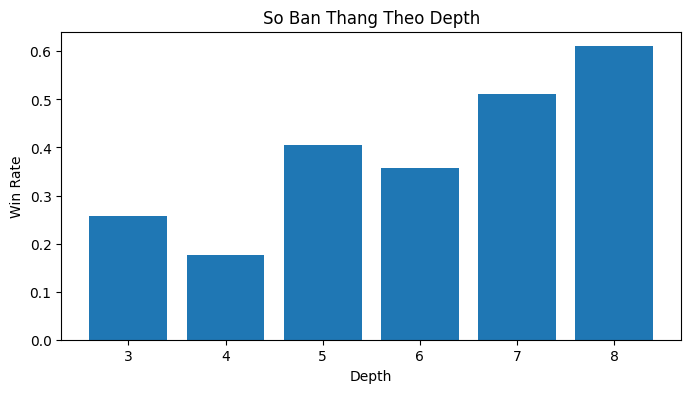

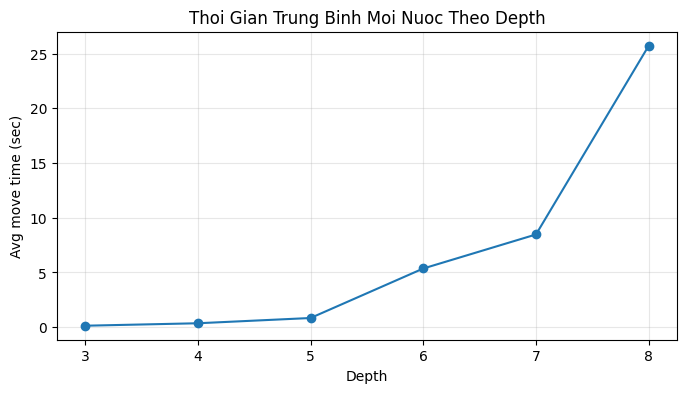

,agent,games,wins,draws,avg_move_sec,avg_moves,win_rate
1,depth_4,74,13,0,0.349623,23.324324,0.175676
7,depth_6_full_a,74,15,0,12.726847,20.270270,0.202703
0,depth_3,74,19,0,0.124389,16.324324,0.256757
8,depth_6_full_b,74,20,0,13.154278,24.689189,0.270270
9,depth_6_plain,74,26,3,2.378247,36.878378,0.351351
30,depth_8_full_a,74,26,0,15.091999,21.513514,0.351351
6,depth_6_cy,74,28,1,2.298654,38.405405,0.378378
11,depth_6_tss,74,28,0,3.720846,24.121622,0.378378
4,depth_6_beam_a,74,28,1,2.237608,35.000000,0.378378
5,depth_6_beam_b,74,30,2,2.274181,33.432432,0.405405


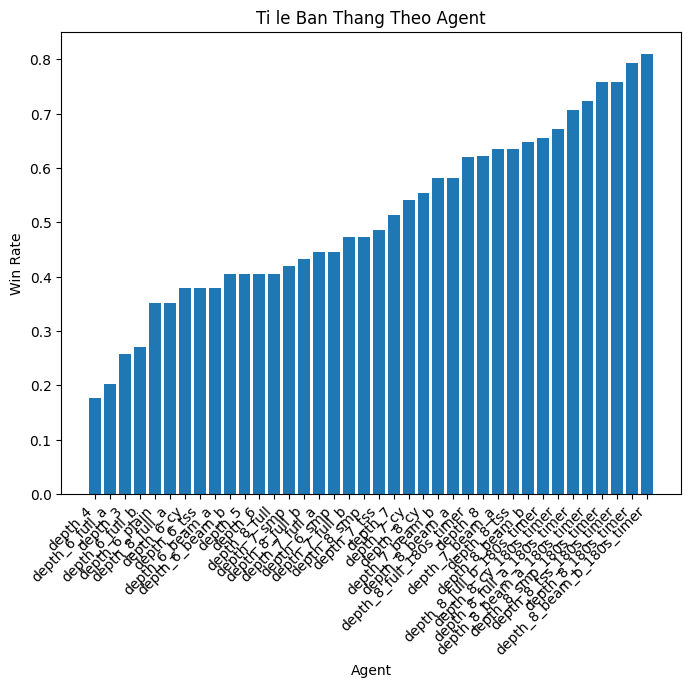

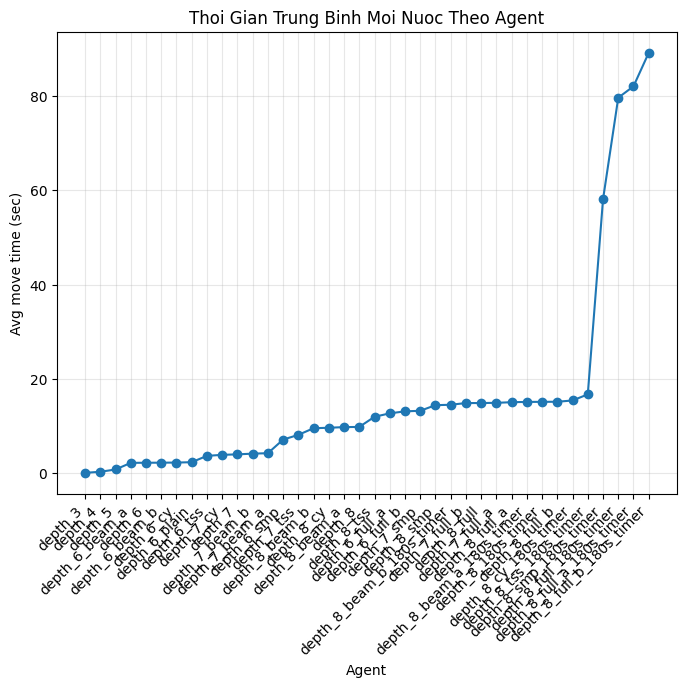

In [47]:
if not df.empty:
    # Expand to per-agent-per-game view
    long_rows = []
    for _, r in df.iterrows():
        x_win = 1 if r['winner'] == r['x_label'] else 0
        o_win = 1 if r['winner'] == r['o_label'] else 0
        x_draw = 1 if r['winner'] == 'draw' else 0
        o_draw = 1 if r['winner'] == 'draw' else 0
        long_rows.append({
            'match_id': r['match_id'], 'side': 'X', 'agent': r['x_label'], 'depth': r['x_depth'],
            'win': x_win, 'draw': x_draw, 'avg_move_sec': r['x_avg_move_sec'], 'moves': r['x_moves']
        })
        long_rows.append({
            'match_id': r['match_id'], 'side': 'O', 'agent': r['o_label'], 'depth': r['o_depth'],
            'win': o_win, 'draw': o_draw, 'avg_move_sec': r['o_avg_move_sec'], 'moves': r['o_moves']
        })
    long_df = pd.DataFrame(long_rows)

    by_depth = long_df.groupby('depth', as_index=False).agg(
        games=('match_id', 'count'),
        wins=('win', 'sum'),
        draws=('draw', 'sum'),
        avg_move_sec=('avg_move_sec', 'mean'),
        avg_moves=('moves', 'mean'),
    )
    by_depth['win_rate'] = by_depth['wins'] / by_depth['games']
    by_depth = by_depth.sort_values('depth')

    display(by_depth)

    plt.figure(figsize=(8, 4))
    plt.bar(by_depth['depth'].astype(str), by_depth['win_rate'])
    plt.title('So Ban Thang Theo Depth')
    plt.xlabel('Depth')
    plt.ylabel('Win Rate')
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(by_depth['depth'], by_depth['avg_move_sec'], marker='o')
    plt.title('Thoi Gian Trung Binh Moi Nuoc Theo Depth')
    plt.xlabel('Depth')
    plt.ylabel('Avg move time (sec)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    
    by_agent = long_df.groupby('agent', as_index=False).agg(
        games=('match_id', 'count'),
        wins=('win', 'sum'),
        draws=('draw', 'sum'),
        avg_move_sec=('avg_move_sec', 'mean'),
        avg_moves=('moves', 'mean'),
    )
    by_agent['win_rate'] = by_agent['wins'] / by_agent['games']
    
    
    by_agent = by_agent.sort_values('win_rate')
    
    display(by_agent)
    
    plt.figure(figsize=(8, 6))
    plt.bar(by_agent['agent'].astype(str), by_agent['win_rate'])
    plt.title('Ti le Ban Thang Theo Agent')
    plt.xlabel('Agent')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Win Rate')
    plt.show()

    by_agent = by_agent.sort_values('avg_move_sec')
    plt.figure(figsize=(8, 6))
    plt.plot(by_agent['agent'], by_agent['avg_move_sec'], marker='o')
    plt.title('Thoi Gian Trung Binh Moi Nuoc Theo Agent')
    plt.xlabel('Agent')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Avg move time (sec)')
    plt.grid(True, alpha=0.3)
    plt.show()


First-player (X) win rate: 0.591
Second-player (O) win rate: 0.405
Draw rate: 0.004
Upset rate (depth thap hon thang): 0.224 (298/1328)


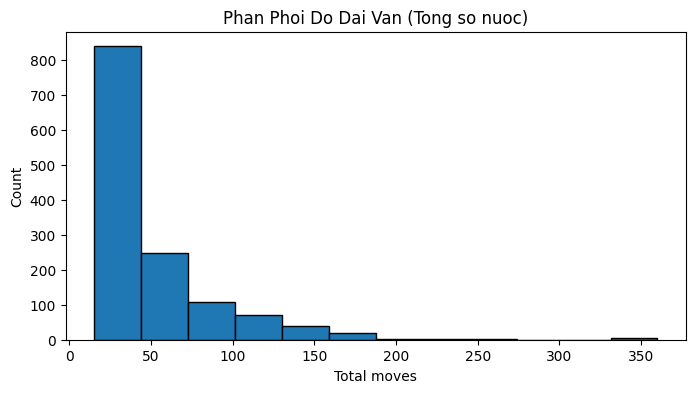

In [48]:
if not df.empty:
    # First-player advantage
    x_win_rate = (df['winner_code'] == 0).mean()
    o_win_rate = (df['winner_code'] == 1).mean()
    draw_rate = (df['winner_code'] == 2).mean()
    print('First-player (X) win rate:', round(x_win_rate, 3))
    print('Second-player (O) win rate:', round(o_win_rate, 3))
    print('Draw rate:', round(draw_rate, 3))

    # Upset rate: depth thap hon thang depth cao hon
    upset = 0
    valid = 0
    for _, r in df.iterrows():
        if r['winner'] == 'draw':
            continue
        valid += 1
        winner_depth = r['x_depth'] if r['winner'] == r['x_label'] else r['o_depth']
        loser_depth = r['o_depth'] if r['winner'] == r['x_label'] else r['x_depth']
        if winner_depth < loser_depth:
            upset += 1
    upset_rate = upset / valid if valid else 0
    print('Upset rate (depth thap hon thang):', round(upset_rate, 3), f'({upset}/{valid})')

    # Game length distribution
    plt.figure(figsize=(8, 4))
    plt.hist(df['total_moves'], bins=12, edgecolor='black')
    plt.title('Phan Phoi Do Dai Van (Tong so nuoc)')
    plt.xlabel('Total moves')
    plt.ylabel('Count')
    plt.show()


In [49]:
# Tra cuu ban co ASCII theo match_id
target_match_id = df['match_id'].iloc[0] if len(df) else None
print('target_match_id =', target_match_id)
if target_match_id:
    print('\n'.join(['=' * 20, target_match_id, '=' * 20]))
    print(boards.get(target_match_id, '[Khong tim thay board ASCII cho match_id nay]'))

target_match_id = depth3_vs_depth4_plain__game_1
depth3_vs_depth4_plain__game_1
completion_index=0
game_seq=1
match_id=depth3_vs_depth4_plain__game_1
winner=depth_4
agent_x={"label": "depth_3", "config": {"depth": 3, "use_cython_search": false, "use_tss": false, "use_lazy_smp": false, "beam_width_root": 0, "beam_width_inner": 0, "move_time_budget_sec": 20}}
agent_o={"label": "depth_4", "config": {"depth": 4, "use_cython_search": false, "use_tss": false, "use_lazy_smp": false, "beam_width_root": 0, "beam_width_inner": 0, "move_time_budget_sec": 20}}
result_for_agent_x=loss
result_for_agent_o=win
. . . . . . . . . . . . . . . . . . . .
. . . . . . . . . . . . O . . . . . . .
. . . . . . . . . X . . X . O . . . . .
. . . . . . . X O O O O X X . . . . . .
. . . . . . . O X O X X X O . . . . . .
. . . . . . . . X O O X X X O . . . . .
. . . . . X . O X X X X O X . . . . . .
. . . . . . O X . O X X O X X . . . . .
. . O . . . . O O X O O O O X O . . . .
. . . X . . . O O X . O X . O . . . . 

=== PERFORMANCE RANKING (win + speed) ===


,agent,depth,games,wins,draws,win_rate,avg_move_sec,performance_score
25,depth_8_beam_b_180s_timer,8,58,47,0,0.810345,14.550619,0.529716
21,depth_8_180s_timer,8,58,46,0,0.793103,15.167009,0.518388
0,depth_3,3,74,19,0,0.256757,0.124389,0.516892
37,depth_8_tss_180s_timer,8,58,44,0,0.758621,16.753805,0.495702
35,depth_8_smp_180s_timer,8,58,44,1,0.758621,58.075969,0.493853
23,depth_8_beam_a_180s_timer,8,58,42,0,0.724138,15.151519,0.473563
31,depth_8_full_a_180s_timer,8,58,41,0,0.706897,82.033855,0.460013
27,depth_8_cy_180s_timer,8,58,39,1,0.672414,15.454984,0.439886
33,depth_8_full_b_180s_timer,8,58,38,0,0.655172,89.132574,0.426351
24,depth_8_beam_b,8,74,48,1,0.648649,9.579246,0.426166


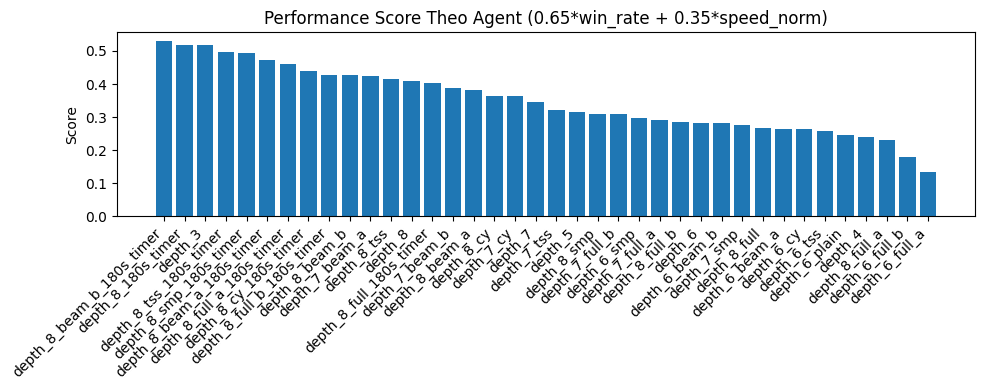

In [50]:
# Performance ranking theo agent/depth (ket hop win + speed)
if not df.empty:
    perf_rows = []
    for _, r in df.iterrows():
        perf_rows.append({
            'agent': r['x_label'],
            'depth': r['x_depth'],
            'win': 1 if r['winner'] == r['x_label'] else 0,
            'draw': 1 if r['winner'] == 'draw' else 0,
            'avg_move_sec': r['x_avg_move_sec'],
            'moves': r['x_moves'],
        })
        perf_rows.append({
            'agent': r['o_label'],
            'depth': r['o_depth'],
            'win': 1 if r['winner'] == r['o_label'] else 0,
            'draw': 1 if r['winner'] == 'draw' else 0,
            'avg_move_sec': r['o_avg_move_sec'],
            'moves': r['o_moves'],
        })

    perf_df = pd.DataFrame(perf_rows)
    ranking = perf_df.groupby(['agent', 'depth'], as_index=False).agg(
        games=('agent', 'count'),
        wins=('win', 'sum'),
        draws=('draw', 'sum'),
        avg_move_sec=('avg_move_sec', 'mean'),
        avg_moves=('moves', 'mean'),
    )
    ranking['win_rate'] = ranking['wins'] / ranking['games']

    # Efficiency score: win_rate uu tien cao, toc do nhanh duoc thuong nhe.
    eps = 1e-9
    ranking['speed_factor'] = 1.0 / (ranking['avg_move_sec'] + eps)
    ranking['speed_factor_norm'] = ranking['speed_factor'] / ranking['speed_factor'].max()
    ranking['performance_score'] = 0.65 * ranking['win_rate'] + 0.35 * ranking['speed_factor_norm']
    ranking = ranking.sort_values(['performance_score', 'win_rate'], ascending=False)

    print('=== PERFORMANCE RANKING (win + speed) ===')
    display(ranking[['agent', 'depth', 'games', 'wins', 'draws', 'win_rate', 'avg_move_sec', 'performance_score']])

    plt.figure(figsize=(10, 4))
    plt.bar(ranking['agent'], ranking['performance_score'])
    plt.xticks(rotation=45, ha='right')
    plt.title('Performance Score Theo Agent (0.65*win_rate + 0.35*speed_norm)')
    plt.ylabel('Score')
    plt.tight_layout()
    plt.show()


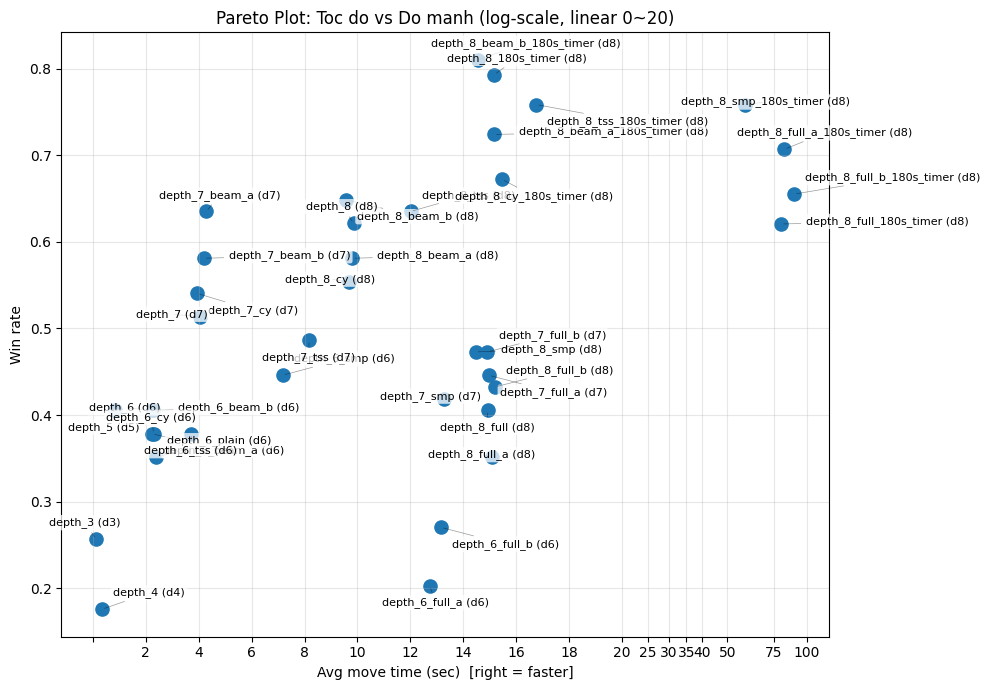

Goi y so sanh: agent nam gan goc tren-phai thuong la can bang tot giua manh va nhanh.


In [51]:
# Pareto view: manh (win_rate cao) va nhanh (avg_move_sec thap)
if not df.empty:
    # reuse ranking from previous cell if exists, otherwise rebuild quickly
    if 'ranking' not in globals():
        perf_rows = []
        for _, r in df.iterrows():
            perf_rows.append({'agent': r['x_label'], 'depth': r['x_depth'], 'win': 1 if r['winner'] == r['x_label'] else 0, 'avg_move_sec': r['x_avg_move_sec']})
            perf_rows.append({'agent': r['o_label'], 'depth': r['o_depth'], 'win': 1 if r['winner'] == r['o_label'] else 0, 'avg_move_sec': r['o_avg_move_sec']})
        perf_df = pd.DataFrame(perf_rows)
        ranking = perf_df.groupby(['agent', 'depth'], as_index=False).agg(games=('agent', 'count'), wins=('win', 'sum'), avg_move_sec=('avg_move_sec', 'mean'))
        ranking['win_rate'] = ranking['wins'] / ranking['games']

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(ranking['avg_move_sec'], ranking['win_rate'], s=90)

    # Reduce label overlap by alternating offsets and adding label boxes.
    rank_for_label = ranking.sort_values(['avg_move_sec', 'win_rate']).reset_index(drop=True)
    offset_pattern = [(-34, 10), (8, 10), (-34, -14), (8, -14), (-46, 0), (18, 0)]
    for i, r in rank_for_label.iterrows():
        ox, oy = offset_pattern[i % len(offset_pattern)]
        ax.annotate(
            f"{r['agent']} (d{int(r['depth'])})",
            (r['avg_move_sec'], r['win_rate']),
            xytext=(ox, oy),
            textcoords='offset points',
            fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.75),
            arrowprops=dict(arrowstyle='-', lw=0.5, alpha=0.4),
        )

    # Scale x theo log nhưng vẫn hiển thị dạng số thường, đặc biệt giãn vùng 0~20.
    import numpy as np
    from matplotlib.ticker import FixedLocator, FuncFormatter

    ax.set_xscale('symlog', linthresh=20, linscale=1.8)  # giãn vùng 0~20

    # Custom x-tick labels là số thường
    def format_xtick(val, _):
        if val >= 1:
            return f"{int(val)}"
        elif val > 0:
            return f"{val:.1f}"
        else:
            return ""

    # Đặt vị trí ticks rõ ràng cho vùng 0-40 để dễ đọc
    xticks = list(np.arange(0, 21, 2)) + list(np.arange(25, 45, 5)) + [50, 75, 100, 150]
    ax.xaxis.set_major_locator(FixedLocator(xticks))
    ax.xaxis.set_major_formatter(FuncFormatter(format_xtick))

    ax.set_xlabel('Avg move time (sec)  [right = faster]')
    ax.set_ylabel('Win rate')
    ax.set_title('Pareto Plot: Toc do vs Do manh (log-scale, linear 0~20)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('Goi y so sanh: agent nam gan goc tren-phai thuong la can bang tot giua manh va nhanh.')


=== ELO ESTIMATE (approx) ===


,agent,elo_estimate
0,depth_8_beam_b_180s_timer,1744.831411
1,depth_8_smp_180s_timer,1717.274257
2,depth_8_180s_timer,1678.806449
3,depth_8_beam_a_180s_timer,1665.118028
4,depth_8_tss_180s_timer,1658.254971
5,depth_8_tss,1637.900562
6,depth_8_full_a_180s_timer,1611.048591
7,depth_8,1610.743436
8,depth_8_cy_180s_timer,1595.326652
9,depth_8_beam_b,1592.539333


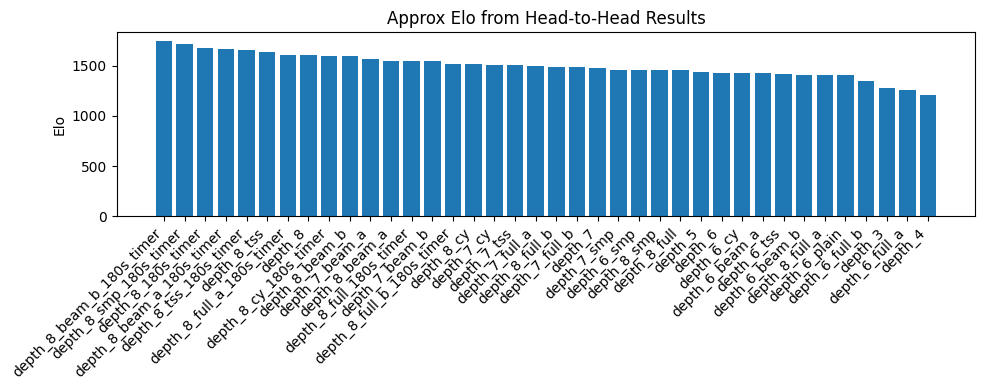

In [52]:
# Elo xap xi tu ket qua doi dau (SGD tren cap ket qua)
import math

if not df.empty:
    # Build match-level outcomes: winner among two agents, draw supported
    matches = []
    for _, r in df.iterrows():
        a = r['x_label']
        b = r['o_label']
        if r['winner'] == 'draw' or r['winner_code'] == 2:
            s_a = 0.5
        elif r['winner'] == a:
            s_a = 1.0
        else:
            s_a = 0.0
        matches.append((a, b, s_a))

    players = sorted(set([m[0] for m in matches] + [m[1] for m in matches]))
    elo = {p: 1500.0 for p in players}
    K = 20.0

    # Multiple passes to stabilize a bit
    for _ in range(20):
        for a, b, s_a in matches:
            ra, rb = elo[a], elo[b]
            ea = 1.0 / (1.0 + 10 ** ((rb - ra) / 400.0))
            delta = K * (s_a - ea)
            elo[a] += delta
            elo[b] -= delta

    elo_df = pd.DataFrame({'agent': list(elo.keys()), 'elo_estimate': list(elo.values())})
    elo_df = elo_df.sort_values('elo_estimate', ascending=False).reset_index(drop=True)

    print('=== ELO ESTIMATE (approx) ===')
    display(elo_df)

    plt.figure(figsize=(10, 4))
    plt.bar(elo_df['agent'], elo_df['elo_estimate'])
    plt.xticks(rotation=45, ha='right')
    plt.title('Approx Elo from Head-to-Head Results')
    plt.ylabel('Elo')
    plt.tight_layout()
    plt.show()


## Form Stability & Slow-Move Risk (before preset)

Các biểu đồ dưới đây đo 3 tín hiệu để hỗ trợ chọn preset khó dễ:
- **Phong độ thất thường**: tần suất agent depth cao thua depth thấp hơn.
- **Rủi ro nước đi chậm**: max elapsed và số lượng nước đi vượt ngưỡng chậm.
- **Biên sai thời gian**: mean vs độ lệch chuẩn/phương sai thời gian mỗi nước đi.

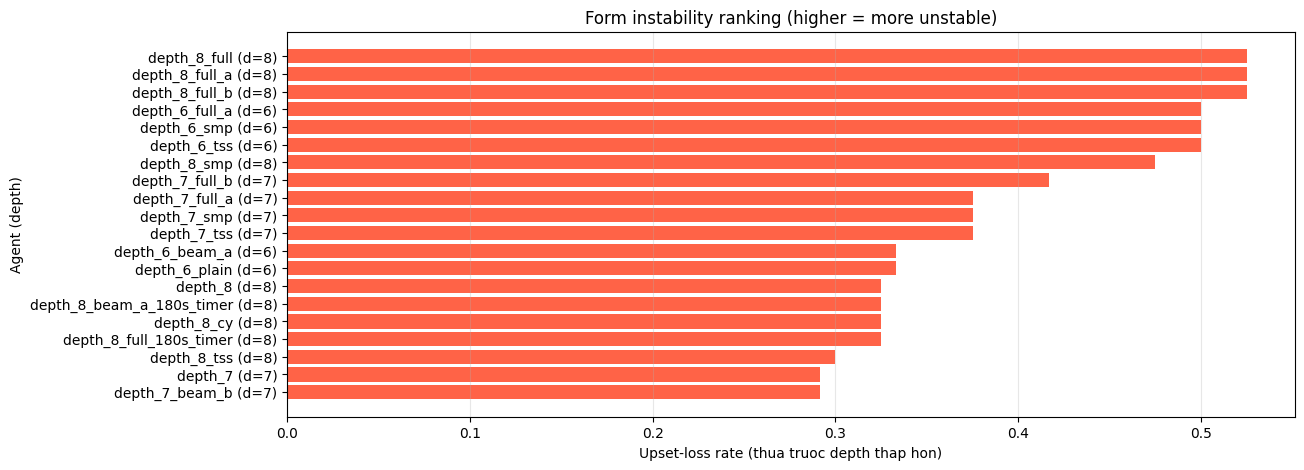

,agent,depth,games,upset_losses,upset_loss_rate,agent_depth
27,depth_8_full,8,40,21,0.525000,depth_8_full (d=8)
29,depth_8_full_a,8,40,21,0.525000,depth_8_full_a (d=8)
31,depth_8_full_b,8,40,21,0.525000,depth_8_full_b (d=8)
6,depth_6_full_a,6,6,3,0.500000,depth_6_full_a (d=6)
9,depth_6_smp,6,6,3,0.500000,depth_6_smp (d=6)
10,depth_6_tss,6,6,3,0.500000,depth_6_tss (d=6)
33,depth_8_smp,8,40,19,0.475000,depth_8_smp (d=8)
16,depth_7_full_b,7,24,10,0.416667,depth_7_full_b (d=7)
15,depth_7_full_a,7,24,9,0.375000,depth_7_full_a (d=7)
17,depth_7_smp,7,24,9,0.375000,depth_7_smp (d=7)


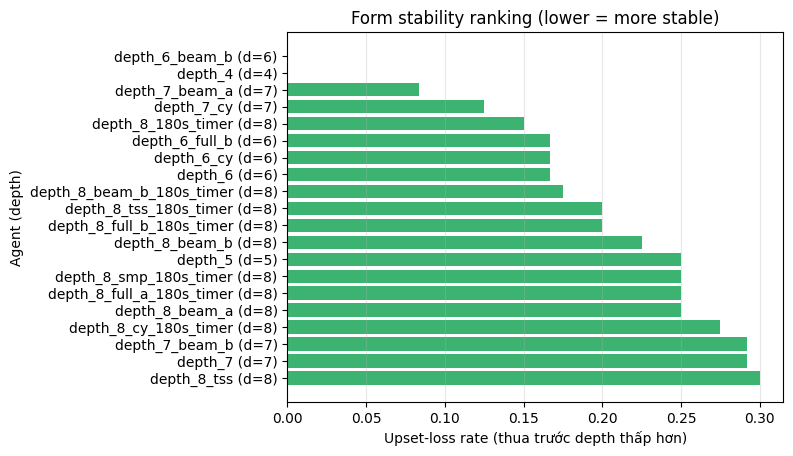

,agent,depth,games,upset_losses,upset_loss_rate,agent_depth
35,depth_8_tss,8,40,12,0.300000,depth_8_tss (d=8)
11,depth_7,7,24,7,0.291667,depth_7 (d=7)
13,depth_7_beam_b,7,24,7,0.291667,depth_7_beam_b (d=7)
26,depth_8_cy_180s_timer,8,40,11,0.275000,depth_8_cy_180s_timer (d=8)
21,depth_8_beam_a,8,40,10,0.250000,depth_8_beam_a (d=8)
30,depth_8_full_a_180s_timer,8,40,10,0.250000,depth_8_full_a_180s_timer (d=8)
34,depth_8_smp_180s_timer,8,40,10,0.250000,depth_8_smp_180s_timer (d=8)
1,depth_5,5,4,1,0.250000,depth_5 (d=5)
23,depth_8_beam_b,8,40,9,0.225000,depth_8_beam_b (d=8)
32,depth_8_full_b_180s_timer,8,40,8,0.200000,depth_8_full_b_180s_timer (d=8)


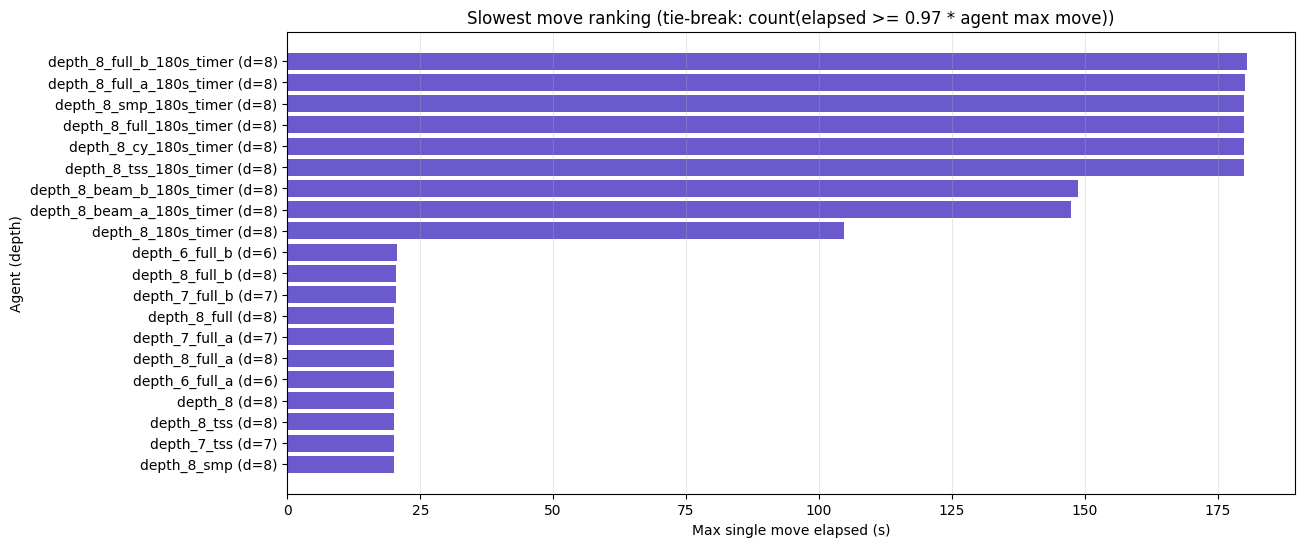

,agent,depth,max_single_move_sec,q95_move_sec,long_move_count,long_move_ratio,total_moves
33,depth_8_full_b_180s_timer,8,180.524,180.04100,199,0.160484,1240
31,depth_8_full_a_180s_timer,8,180.104,180.03500,192,0.154217,1245
35,depth_8_smp_180s_timer,8,180.061,180.01900,128,0.062592,2045
29,depth_8_full_180s_timer,8,180.047,180.02805,109,0.106863,1020
27,depth_8_cy_180s_timer,8,180.022,65.10200,7,0.003597,1946
37,depth_8_tss_180s_timer,8,180.022,50.98555,1,0.001010,990
25,depth_8_beam_b_180s_timer,8,148.824,56.57450,1,0.000560,1786
23,depth_8_beam_a_180s_timer,8,147.367,52.42770,1,0.000538,1859
21,depth_8_180s_timer,8,104.671,45.14500,1,0.000540,1853
8,depth_6_full_b,6,20.563,20.08270,967,0.529283,1827


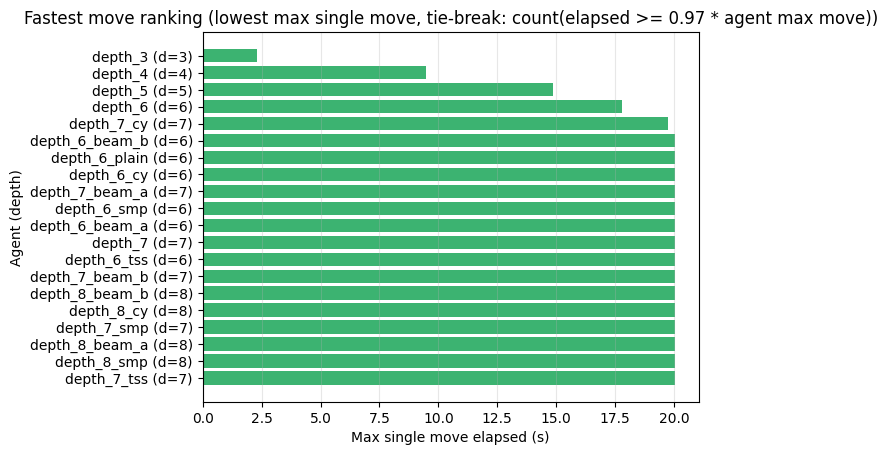

,agent,depth,max_single_move_sec,q95_move_sec,long_move_count,long_move_ratio,total_moves
19,depth_7_tss,7,20.041,20.01500,239,0.158488,1508
34,depth_8_smp,8,20.037,20.02300,1478,0.732771,2017
22,depth_8_beam_a,8,20.036,20.01700,490,0.265295,1847
18,depth_7_smp,7,20.034,20.02100,1091,0.499771,2183
26,depth_8_cy,8,20.034,20.01600,449,0.230848,1945
24,depth_8_beam_b,8,20.032,20.01600,461,0.240229,1919
14,depth_7_beam_b,7,20.031,11.21365,8,0.005563,1438
11,depth_6_tss,6,20.029,12.15520,12,0.006723,1785
12,depth_7,7,20.027,11.23755,14,0.010145,1380
4,depth_6_beam_a,6,20.025,8.53615,3,0.001158,2590


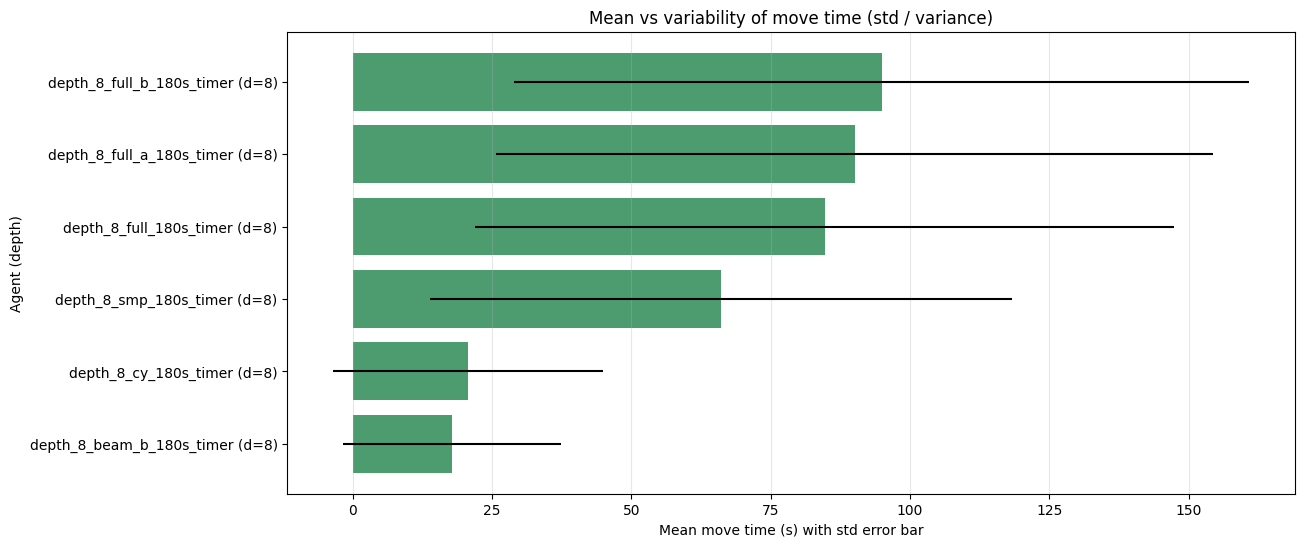

,agent,depth,move_mean_sec,move_std_sec,move_var_sec,q95_move_sec,max_single_move_sec,total_moves
33,depth_8_full_b_180s_timer,8,94.926035,65.945724,4348.838502,180.04100,180.524,1240
31,depth_8_full_a_180s_timer,8,90.041810,64.392104,4146.343034,180.03500,180.104,1245
29,depth_8_full_180s_timer,8,84.666462,62.789331,3942.500088,180.02805,180.047,1020
35,depth_8_smp_180s_timer,8,66.100620,52.216869,2726.601387,180.01900,180.061,2045
27,depth_8_cy_180s_timer,8,20.657863,24.196602,585.475543,65.10200,180.022,1946
25,depth_8_beam_b_180s_timer,8,17.737261,19.578793,383.329142,56.57450,148.824,1786
37,depth_8_tss_180s_timer,8,17.674219,18.302417,334.978453,50.98555,180.022,990
23,depth_8_beam_a_180s_timer,8,17.365568,17.772744,315.870412,52.42770,147.367,1859
21,depth_8_180s_timer,8,16.301331,15.394696,236.996678,45.14500,104.671,1853
32,depth_8_full_b,8,14.979886,8.687259,75.468464,20.06640,20.496,1573


[INFO] slow_move_features ready. long-move = elapsed >= 0.97 * agent max move


In [53]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def _nb_get(name):
    try:
        ip = get_ipython()
    except NameError:
        ip = None
    if ip is not None and name in ip.user_ns:
        return ip.user_ns[name]
    return globals().get(name)


def _resolve_fragments_dir():
    p = _nb_get('fragments_dir')
    if isinstance(p, Path) and p.is_dir():
        return p
    p2 = _nb_get('boards_path')
    if isinstance(p2, Path):
        cand = p2.parent / 'fragments'
        if cand.is_dir():
            return cand
    here = Path.cwd().resolve()
    for root in (here, here.parent):
        cand = root / 'benchmarks' / 'results' / 'fragments'
        if cand.is_dir():
            return cand
    return None


def _parse_match_meta(summary_path: Path):
    match_id, x_label, o_label, x_depth, o_depth = None, None, None, None, None
    for ln in summary_path.read_text(encoding='utf-8').splitlines():
        if ln.startswith('match_id='):
            match_id = ln.split('=', 1)[1].strip()
        elif ln.startswith('agent_x='):
            obj = json.loads(ln.split('=', 1)[1].strip())
            x_label = obj.get('label')
            x_depth = (obj.get('config') or {}).get('depth')
        elif ln.startswith('agent_o='):
            obj = json.loads(ln.split('=', 1)[1].strip())
            o_label = obj.get('label')
            o_depth = (obj.get('config') or {}).get('depth')
    return {
        'match_id': match_id,
        'x_label': x_label,
        'o_label': o_label,
        'x_depth': x_depth,
        'o_depth': o_depth,
    }


_MOVE_RE = re.compile(r'^actor=(.*?);\s*piece=([XO]);\s*elapsed=([0-9]+(?:\.[0-9]+)?)s;')


def _collect_move_elapsed_df(frags_dir: Path) -> pd.DataFrame:
    rows = []
    for sub in sorted(frags_dir.iterdir()):
        if not sub.is_dir():
            continue
        sp = sub / 'summary.txt'
        mp = sub / 'moves.txt'
        if not sp.exists() or not mp.exists():
            continue
        meta = _parse_match_meta(sp)
        if not meta['match_id']:
            continue

        for ln in mp.read_text(encoding='utf-8').splitlines():
            m = _MOVE_RE.match(ln.strip())
            if not m:
                continue
            actor = m.group(1).strip()
            elapsed = float(m.group(3))
            if actor == meta['x_label']:
                depth = meta['x_depth']
            elif actor == meta['o_label']:
                depth = meta['o_depth']
            else:
                depth = np.nan
            rows.append(
                {
                    'match_id': meta['match_id'],
                    'agent': actor,
                    'depth': depth,
                    'elapsed_sec': elapsed,
                }
            )
    out = pd.DataFrame(rows)
    if not out.empty:
        out['depth'] = pd.to_numeric(out['depth'], errors='coerce')
        out = out.dropna(subset=['depth']).copy()
        out['depth'] = out['depth'].astype(int)
    return out


_df = _nb_get('df')
if _df is None or _df.empty:
    print('Can co df tu parse_summary truoc khi ve bieu do nay.')
else:
    frags_dir = _resolve_fragments_dir()
    move_elapsed_df = pd.DataFrame()
    slow_move_features = pd.DataFrame()

    if frags_dir is None:
        print('Khong tim thay thu muc fragments; bo qua 2 bieu do phu thuoc move log.')
    else:
        move_elapsed_df = _collect_move_elapsed_df(frags_dir)

    # (1) Phong do that thuong: depth cao thua depth thap hon.
    upset_rows = []
    for _, r in _df.iterrows():
        xd, od = r.get('x_depth'), r.get('o_depth')
        if pd.isna(xd) or pd.isna(od) or xd == od:
            continue
        winner = r.get('winner')
        if xd > od:
            stronger_agent, stronger_depth = r['x_label'], int(xd)
            weaker_agent = r['o_label']
        else:
            stronger_agent, stronger_depth = r['o_label'], int(od)
            weaker_agent = r['x_label']
        upset = 1 if winner == weaker_agent else 0
        upset_rows.append({'agent': stronger_agent, 'depth': stronger_depth, 'upset_loss': upset})

    upset_df = pd.DataFrame(upset_rows)
    if upset_df.empty:
        print('Khong co cap depth khac nhau de tinh upset-loss rate.')
        upset_rank = pd.DataFrame()
    else:
        upset_rank = upset_df.groupby(['agent', 'depth'], as_index=False).agg(
            games=('upset_loss', 'count'),
            upset_losses=('upset_loss', 'sum'),
        )
        upset_rank['upset_loss_rate'] = upset_rank['upset_losses'] / upset_rank['games']
        upset_rank['agent_depth'] = upset_rank['agent'] + ' (d=' + upset_rank['depth'].astype(str) + ')'
        upset_rank = upset_rank.sort_values(['upset_loss_rate', 'upset_losses'], ascending=[False, False])

        plt.figure(figsize=(13, 5))
        view = upset_rank.head(20).iloc[::-1]
        plt.barh(view['agent_depth'], view['upset_loss_rate'], color='tomato')
        plt.xlabel('Upset-loss rate (thua truoc depth thap hon)')
        plt.ylabel('Agent (depth)')
        plt.title('Form instability ranking (higher = more unstable)')
        plt.grid(axis='x', alpha=0.3)
        plt.show()
        display(upset_rank.head(20))

        # Biểu đồ đối lập: Các agent có upset-loss rate thấp nhất (ổn định nhất)
        view = upset_rank.tail(20)
        plt.barh(view['agent_depth'], view['upset_loss_rate'], color='mediumseagreen')
        plt.xlabel('Upset-loss rate (thua trước depth thấp hơn)')
        plt.ylabel('Agent (depth)')
        plt.title('Form stability ranking (lower = more stable)')
        plt.grid(axis='x', alpha=0.3)
        plt.show()
        display(upset_rank.tail(20))
 

    if not move_elapsed_df.empty:
        # Dinh nghia long_move theo agent/depth: elapsed >= delta * max_single_move cua chinh agent/depth do.
        long_move_delta_ratio = 0.97

        def agent_group_long_count(group, delta_ratio=long_move_delta_ratio):
            max_single = group['elapsed_sec'].max()
            if pd.isna(max_single) or max_single <= 0:
                return 0
            thr = max_single * delta_ratio
            return int((group['elapsed_sec'] >= thr).sum())

        agg = move_elapsed_df.groupby(['agent', 'depth']).agg(
            total_moves=('elapsed_sec', 'count'),
            move_mean_sec=('elapsed_sec', 'mean'),
            move_std_sec=('elapsed_sec', 'std'),
            move_var_sec=('elapsed_sec', 'var'),
            max_single_move_sec=('elapsed_sec', 'max'),
            q95_move_sec=('elapsed_sec', lambda s: float(s.quantile(0.95))),
        ).reset_index()

        long_counts = (
            move_elapsed_df
            .groupby(['agent', 'depth'], group_keys=False)
            .apply(lambda g: agent_group_long_count(g, long_move_delta_ratio))
            .reset_index(name='long_move_count')
        )
        agg = agg.merge(long_counts, on=['agent', 'depth'], how='left')
        agg['long_move_count'] = agg['long_move_count'].fillna(0).astype(int)
        agg['move_std_sec'] = agg['move_std_sec'].fillna(0.0)
        agg['move_var_sec'] = agg['move_var_sec'].fillna(0.0)
        agg['long_move_ratio'] = agg['long_move_count'] / agg['total_moves'].clip(lower=1)
        agg['agent_depth'] = agg['agent'] + ' (d=' + agg['depth'].astype(str) + ')'
        slow_move_features = agg.copy()

        # (2) Xep hang nuoc di cham: uu tien max elapsed, neu bang nhau uu tien long_move_count.
        slow_rank = agg.sort_values(['max_single_move_sec', 'long_move_count', 'q95_move_sec'], ascending=False)
        plt.figure(figsize=(13, 6))
        view = slow_rank.head(20).iloc[::-1]
        plt.barh(view['agent_depth'], view['max_single_move_sec'], color='slateblue')
        plt.xlabel('Max single move elapsed (s)')
        plt.ylabel('Agent (depth)')
        plt.title(
            f'Slowest move ranking (tie-break: count(elapsed >= {long_move_delta_ratio:.2f} * agent max move))'
        )
        plt.grid(axis='x', alpha=0.3)
        plt.show()
        display(slow_rank[['agent', 'depth', 'max_single_move_sec', 'q95_move_sec', 'long_move_count', 'long_move_ratio', 'total_moves']].head(20))

        # Bieu do doi lap: cac agent co max single move thap nhat.
        view = slow_rank.tail(20)
        plt.barh(view['agent_depth'], view['max_single_move_sec'], color='mediumseagreen')
        plt.xlabel('Max single move elapsed (s)')
        plt.ylabel('Agent (depth)')
        plt.title(
            f'Fastest move ranking (lowest max single move, tie-break: count(elapsed >= {long_move_delta_ratio:.2f} * agent max move))'
        )
        plt.grid(axis='x', alpha=0.3)
        plt.show()
        display(slow_rank[['agent', 'depth', 'max_single_move_sec', 'q95_move_sec', 'long_move_count', 'long_move_ratio', 'total_moves']].tail(20))

        # (3) Bien sai / phuong sai quanh mean thoi gian moi nuoc.
        spread_rank = agg.sort_values('move_std_sec', ascending=False)
        plt.figure(figsize=(13, 6))
        view = spread_rank.head(6).iloc[::-1]
        plt.barh(view['agent_depth'], view['move_mean_sec'], xerr=view['move_std_sec'], color='seagreen', alpha=0.85)
        plt.xlabel('Mean move time (s) with std error bar')
        plt.ylabel('Agent (depth)')
        plt.title('Mean vs variability of move time (std / variance)')
        plt.grid(axis='x', alpha=0.3)
        plt.show()
        display(spread_rank[['agent', 'depth', 'move_mean_sec', 'move_std_sec', 'move_var_sec', 'q95_move_sec', 'max_single_move_sec', 'total_moves']].head(20))

        # Expose for preset scoring cell.
        LONG_MOVE_DELTA_RATIO = long_move_delta_ratio
        globals()['LONG_MOVE_DELTA_RATIO'] = LONG_MOVE_DELTA_RATIO
        globals()['slow_move_features'] = slow_move_features
        globals()['move_elapsed_df'] = move_elapsed_df
        print(f'[INFO] slow_move_features ready. long-move = elapsed >= {LONG_MOVE_DELTA_RATIO:.2f} * agent max move')

## Difficulty preset selection (Easy / Medium / Hard)

This section suggests **one (agent label, depth)** row from the benchmark summary for each UI tier.

### Criteria

1. **Performance score** (same weighting as above):  
   `0.65 * win_rate + 0.35 * speed_factor_norm`, but **speed is adjusted** for bad spikes: if some games are much slower than the agent’s typical average, the effective speed factor is reduced (worst-game average vs mean).
2. **Elo** (approximate, from the head-to-head cell): used as a **tie-breaker** after the adjusted performance score.
3. **Time budget** on **mean seconds per move** (`avg_move_sec` over games):  
   - **Easy** &lt; 1 s  
   - **Medium** &lt; 4 s  
   - **Hard** &lt; 20 s  
4. **Spike guard**: exclude configs whose **slowest single-game** average move time exceeds `budget × 1.75` for that tier (avoid agents that are usually fast but occasionally stall).

**Prerequisite:** `pandas` (`pd`) must be imported (first code cell). This cell reads `df` from the Jupyter **user namespace** (not only `globals()`, for VS Code / Cursor compatibility), then tries `benchmarks/results/benchmark_results_summary.txt` under `Path.cwd()` and its parent. If `perf_df` / `ranking` or `elo_df` are missing, it rebuilds them from `df`. Tunables: `SPIKE_MULT`, `SPIKE_PENALTY_WEIGHT` in the code cell below.

In [54]:
# Chon agent/depth cho Easy / Medium / Hard (performance + Elo + thoi gian + spike + long-move risk)
import json
import numpy as np
from pathlib import Path


SPIKE_MULT = 1.75  # max single-game avg move / tier budget
SPIKE_PENALTY_WEIGHT = 0.35  # giam speed_factor khi worst-game cham hon mean
LONG_MOVE_PENALTY_WEIGHT = 0.15  # phat nang agent co nhieu nuoc di cham


def _nb_get(name):
    """Bien notebook: Jupyter luu o user_ns; mot so IDE khong dong bo voi globals()."""
    try:
        ip = get_ipython()
    except NameError:
        ip = None
    if ip is not None and name in ip.user_ns:
        return ip.user_ns[name]
    return globals().get(name)


LONG_MOVE_DELTA_RATIO = _nb_get('LONG_MOVE_DELTA_RATIO') or 0.97


def _resolve_summary_path():
    p = _nb_get('summary_path')
    if isinstance(p, Path) and p.is_file():
        return p
    here = Path.cwd().resolve()
    roots = {here, here.parent}
    for root in roots:
        cand = root / 'benchmarks' / 'results' / 'benchmark_results_summary.txt'
        if cand.is_file():
            return cand
    return None


def _load_df_from_summary(path: Path):
    def _blocks(text: str):
        blocks, cur = [], []
        for line in text.splitlines():
            if line.strip() == '':
                if cur:
                    blocks.append(cur)
                    cur = []
            else:
                cur.append(line)
        if cur:
            blocks.append(cur)
        return blocks

    text = path.read_text(encoding='utf-8')
    rows = []
    for block in _blocks(text):
        kv = {}
        for ln in block:
            if '=' in ln:
                k, v = ln.split('=', 1)
                kv[k.strip()] = v.strip()
        if 'match_id' not in kv:
            continue
        agent_x = json.loads(kv['agent_x'])
        agent_o = json.loads(kv['agent_o'])
        stats = json.loads(kv['stats'])
        row = {
            'match_id': kv['match_id'],
            'winner': kv.get('winner', 'unknown'),
            'winner_code': stats.get('winner_code', None),
            'x_label': agent_x['label'],
            'o_label': agent_o['label'],
            'x_depth': agent_x['config'].get('depth'),
            'o_depth': agent_o['config'].get('depth'),
            'x_avg_move_sec': stats.get('x_avg_move_sec', 0.0),
            'o_avg_move_sec': stats.get('o_avg_move_sec', 0.0),
            'x_moves': stats.get('x_moves', 0),
            'o_moves': stats.get('o_moves', 0),
        }
        row['total_moves'] = row['x_moves'] + row['o_moves']
        row['avg_depth'] = (
            (row['x_depth'] + row['o_depth']) / 2
            if row['x_depth'] and row['o_depth']
            else None
        )
        rows.append(row)
    out = pd.DataFrame(rows)
    if not out.empty:
        for c in ['x_depth', 'o_depth', 'x_moves', 'o_moves', 'total_moves']:
            out[c] = pd.to_numeric(out[c], errors='coerce')
        for c in ['x_avg_move_sec', 'o_avg_move_sec']:
            out[c] = pd.to_numeric(out[c], errors='coerce')
    return out


_df = _nb_get('df')
if _df is None:
    _parse = _nb_get('parse_summary')
    _spath = _resolve_summary_path() or _nb_get('summary_path')
    if isinstance(_spath, Path) and _spath.is_file():
        if callable(_parse):
            _df = _parse(_spath)
        else:
            _df = _load_df_from_summary(_spath)

if _df is None:
    _tried = _resolve_summary_path()
    print(
        'Khong load duoc df. cwd =', Path.cwd(),
        '| summary tim thay:', _tried,
    )
    print(
        'Chay cell import + parse summary, hoac dat file tai '
        '<repo>/benchmarks/results/benchmark_results_summary.txt'
    )
elif _df.empty:
    print('Khong co du lieu benchmark (file summary rong).')
else:
    df = _df

    perf_df = _nb_get('perf_df')
    ranking = _nb_get('ranking')
    if perf_df is None or ranking is None:
        perf_rows = []
        for _, r in df.iterrows():
            perf_rows.append(
                {
                    'agent': r['x_label'],
                    'depth': r['x_depth'],
                    'win': 1 if r['winner'] == r['x_label'] else 0,
                    'draw': 1 if r['winner'] == 'draw' else 0,
                    'avg_move_sec': r['x_avg_move_sec'],
                    'moves': r['x_moves'],
                }
            )
            perf_rows.append(
                {
                    'agent': r['o_label'],
                    'depth': r['o_depth'],
                    'win': 1 if r['winner'] == r['o_label'] else 0,
                    'draw': 1 if r['winner'] == 'draw' else 0,
                    'avg_move_sec': r['o_avg_move_sec'],
                    'moves': r['o_moves'],
                }
            )
        perf_df = pd.DataFrame(perf_rows)
        ranking = perf_df.groupby(['agent', 'depth'], as_index=False).agg(
            games=('agent', 'count'),
            wins=('win', 'sum'),
            draws=('draw', 'sum'),
            avg_move_sec=('avg_move_sec', 'mean'),
            avg_moves=('moves', 'mean'),
        )
        ranking['win_rate'] = ranking['wins'] / ranking['games']
        _eps0 = 1e-9
        ranking['speed_factor'] = 1.0 / (ranking['avg_move_sec'] + _eps0)
        ranking['speed_factor_norm'] = ranking['speed_factor'] / ranking['speed_factor'].max()
        ranking['performance_score'] = (
            0.65 * ranking['win_rate'] + 0.35 * ranking['speed_factor_norm']
        )
        ranking = ranking.sort_values(['performance_score', 'win_rate'], ascending=False)

    elo_df = _nb_get('elo_df')
    if elo_df is None:
        matches = []
        for _, r in df.iterrows():
            a = r['x_label']
            b = r['o_label']
            if r['winner'] == 'draw' or r.get('winner_code') == 2:
                s_a = 0.5
            elif r['winner'] == a:
                s_a = 1.0
            else:
                s_a = 0.0
            matches.append((a, b, s_a))
        players = sorted(set([m[0] for m in matches] + [m[1] for m in matches]))
        elo = {p: 1500.0 for p in players}
        K = 20.0
        for _ in range(20):
            for a, b, s_a in matches:
                ra, rb = elo[a], elo[b]
                ea = 1.0 / (1.0 + 10 ** ((rb - ra) / 400.0))
                delta = K * (s_a - ea)
                elo[a] += delta
                elo[b] -= delta
        elo_df = pd.DataFrame({'agent': list(elo.keys()), 'elo_estimate': list(elo.values())})
        elo_df = elo_df.sort_values('elo_estimate', ascending=False).reset_index(drop=True)

    spike = perf_df.groupby(['agent', 'depth'], as_index=False).agg(
        max_game_avg_move_sec=('avg_move_sec', 'max'),
    )
    sel = ranking.merge(spike, on=['agent', 'depth'], how='left')
    sel = sel.merge(elo_df[['agent', 'elo_estimate']], on='agent', how='left')

    # Dong bo dinh nghia long_move voi cell Slow-Move Risk (elapsed >= delta * max_single_move theo agent/depth).
    move_elapsed_df = _nb_get('move_elapsed_df')
    if isinstance(move_elapsed_df, pd.DataFrame) and not move_elapsed_df.empty:
        _mv = move_elapsed_df[['agent', 'depth', 'elapsed_sec']].copy()
        _mv['depth'] = pd.to_numeric(_mv['depth'], errors='coerce')
        _mv = _mv.dropna(subset=['depth'])
        _mv['depth'] = _mv['depth'].astype(int)

        max_by_group = _mv.groupby(['agent', 'depth'])['elapsed_sec'].transform('max')
        _mv['is_long_move'] = _mv['elapsed_sec'] >= (LONG_MOVE_DELTA_RATIO * max_by_group)

        long_feat = _mv.groupby(['agent', 'depth'], as_index=False).agg(
            total_moves=('elapsed_sec', 'count'),
            max_single_move_sec=('elapsed_sec', 'max'),
            q95_move_sec=('elapsed_sec', lambda s: float(s.quantile(0.95))),
            long_move_count=('is_long_move', 'sum'),
            move_std_sec=('elapsed_sec', 'std'),
            move_var_sec=('elapsed_sec', 'var'),
        )
        long_feat['move_std_sec'] = long_feat['move_std_sec'].fillna(0.0)
        long_feat['move_var_sec'] = long_feat['move_var_sec'].fillna(0.0)
        long_feat['long_move_count'] = long_feat['long_move_count'].astype(int)
        long_feat['long_move_ratio'] = long_feat['long_move_count'] / long_feat['total_moves'].clip(lower=1)

        sel = sel.merge(
            long_feat[
                [
                    'agent', 'depth', 'max_single_move_sec', 'q95_move_sec',
                    'long_move_count', 'long_move_ratio', 'move_std_sec', 'move_var_sec'
                ]
            ],
            on=['agent', 'depth'],
            how='left',
        )
    else:
        slow_features = _nb_get('slow_move_features')
        if isinstance(slow_features, pd.DataFrame) and not slow_features.empty:
            needed = [
                'agent', 'depth', 'max_single_move_sec', 'q95_move_sec',
                'long_move_count', 'long_move_ratio', 'move_std_sec', 'move_var_sec'
            ]
            cols = [c for c in needed if c in slow_features.columns]
            sel = sel.merge(slow_features[cols], on=['agent', 'depth'], how='left')
        else:
            # Fallback khi chua chay cell phan tich move log.
            sel['max_single_move_sec'] = np.nan
            sel['q95_move_sec'] = np.nan
            sel['long_move_count'] = 0
            sel['long_move_ratio'] = 0.0
            sel['move_std_sec'] = 0.0
            sel['move_var_sec'] = 0.0

    _elo_med = sel['elo_estimate'].median()
    sel['elo_estimate'] = sel['elo_estimate'].fillna(
        _elo_med if pd.notna(_elo_med) else 0.0
    )

    sel['long_move_count'] = pd.to_numeric(sel['long_move_count'], errors='coerce').fillna(0).astype(int)
    sel['long_move_ratio'] = pd.to_numeric(sel['long_move_ratio'], errors='coerce').fillna(0.0)
    sel['max_single_move_sec'] = pd.to_numeric(sel['max_single_move_sec'], errors='coerce')
    sel['q95_move_sec'] = pd.to_numeric(sel['q95_move_sec'], errors='coerce')

    eps = 1e-9
    sel['spike_excess'] = (sel['max_game_avg_move_sec'] - sel['avg_move_sec']).clip(lower=0)
    rel_spike = sel['spike_excess'] / (sel['avg_move_sec'] + eps)
    sel['speed_factor'] = 1.0 / (sel['avg_move_sec'] + eps)
    sel['speed_factor_adj'] = sel['speed_factor'] * (1.0 - SPIKE_PENALTY_WEIGHT * rel_spike.clip(0, 2.0))
    sel['speed_factor_adj'] = sel['speed_factor_adj'].clip(lower=1e-9)
    sel['speed_factor_norm_adj'] = sel['speed_factor_adj'] / sel['speed_factor_adj'].max()
    sel['performance_score_adj'] = 0.65 * sel['win_rate'] + 0.35 * sel['speed_factor_norm_adj']

    tiers = [
        ('easy', 1.0, 0.0),
        ('medium', 6.0, 0.35),
        ('hard', 20.0, 0.5),
    ]

    print(
        '=== DEPTH PRESET SUGGESTIONS (mean + spike + long-move risk + perf + Elo) ===\n'
        f'[long_move: elapsed >= {LONG_MOVE_DELTA_RATIO:.2f} * max_single_move(agent/depth)]'
    )
    picks = []
    for name, budget, min_win_rate in tiers:
        cap_spike = budget * SPIKE_MULT
        cand = sel[
            (sel['avg_move_sec'] < budget)
            & (sel['max_game_avg_move_sec'] <= cap_spike)
            & (sel['win_rate'] >= min_win_rate)
        ].copy()

        # Phat them theo tan suat va so luong nuoc di cham.
        max_long_count = max(int(cand['long_move_count'].max()) if not cand.empty else 0, 1)
        cand['long_move_count_norm'] = cand['long_move_count'] / max_long_count
        cand['long_move_penalty'] = 0.7 * cand['long_move_ratio'] + 0.3 * cand['long_move_count_norm']

        # Neu co max_single_move, phat them theo vuot ngan sach tier.
        cand['single_move_over_budget'] = (
            (cand['max_single_move_sec'] - cap_spike) / max(cap_spike, 1e-9)
        ).clip(lower=0).fillna(0.0)

        cand['tier_score'] = (
            cand['performance_score_adj']
            - LONG_MOVE_PENALTY_WEIGHT * cand['long_move_penalty']
            - 0.20 * cand['single_move_over_budget']
        )

        cand = cand.sort_values(
            ['tier_score', 'performance_score_adj', 'elo_estimate', 'win_rate'],
            ascending=False,
        )
        top = cand.head(10)

        print(f'\n--- {name.upper()} (mean < {budget}s, worst-game avg <= {cap_spike:.2f}s) ---')
        if top.empty:
            print('Khong co ung vien thoa dieu kien; thu noi long SPIKE_MULT hoac budget.')
        else:
            display(
                top[
                    [
                        'agent',
                        'depth',
                        'games',
                        'wins',
                        'win_rate',
                        'avg_move_sec',
                        'max_game_avg_move_sec',
                        'max_single_move_sec',
                        'long_move_count',
                        'long_move_ratio',
                        'performance_score_adj',
                        'tier_score',
                        'elo_estimate',
                    ]
                ]
            )
            best = top.iloc[0]
            picks.append(
                {
                    'tier': name,
                    'agent': best['agent'],
                    'depth': best['depth'],
                    'win_rate': best['win_rate'],
                    'avg_move_sec': best['avg_move_sec'],
                    'max_game_avg_move_sec': best['max_game_avg_move_sec'],
                    'max_single_move_sec': best.get('max_single_move_sec', np.nan),
                    'long_move_count': int(best.get('long_move_count', 0)),
                    'long_move_ratio': best.get('long_move_ratio', 0.0),
                    'performance_score_adj': best['performance_score_adj'],
                    'tier_score': best['tier_score'],
                    'elo_estimate': best['elo_estimate'],
                }
            )

    if picks:
        preset_df = pd.DataFrame(picks)
        print('\n=== TOM TAT LUA CHON (hang dau moi cap) ===')
        display(preset_df)


=== DEPTH PRESET SUGGESTIONS (mean + spike + long-move risk + perf + Elo) ===
[long_move: elapsed >= 0.97 * max_single_move(agent/depth)]

--- EASY (mean < 1.0s, worst-game avg <= 1.75s) ---


,agent,depth,games,wins,win_rate,avg_move_sec,max_game_avg_move_sec,max_single_move_sec,long_move_count,long_move_ratio,performance_score_adj,tier_score,elo_estimate
2,depth_3,3,74,19,0.256757,0.124389,1.049,2.286,2,0.001656,0.516892,0.410461,1279.511182



--- MEDIUM (mean < 6.0s, worst-game avg <= 10.50s) ---


,agent,depth,games,wins,win_rate,avg_move_sec,max_game_avg_move_sec,max_single_move_sec,long_move_count,long_move_ratio,performance_score_adj,tier_score,elo_estimate
10,depth_7_beam_a,7,74,47,0.635135,4.283203,8.1184,20.023,9,0.007299,0.436101,0.230121,1563.267707
20,depth_5,5,74,30,0.405405,0.829788,6.6543,14.884,1,0.000601,0.315980,0.229765,1432.799548
14,depth_7_beam_b,7,74,43,0.581081,4.188454,8.1686,20.031,8,0.005563,0.400827,0.197523,1546.466434
17,depth_7_cy,7,74,40,0.540541,3.935505,7.1535,19.726,2,0.001661,0.377673,0.196471,1510.886352
26,depth_6,6,74,30,0.405405,2.261719,4.2897,17.773,1,0.000395,0.307541,0.166319,1427.265478
18,depth_7,7,74,38,0.513514,4.038593,7.3743,20.027,14,0.010145,0.359329,0.139739,1475.593226
30,depth_6_beam_a,6,74,28,0.378378,2.237608,5.6141,20.025,3,0.001158,0.276549,0.087057,1422.345953
27,depth_6_beam_b,6,74,30,0.405405,2.274181,6.1945,20.019,8,0.003234,0.288825,0.085995,1411.029936
31,depth_6_cy,6,74,28,0.378378,2.298654,5.3985,20.021,6,0.002111,0.279281,0.081824,1423.286804
32,depth_6_tss,6,74,28,0.378378,3.720846,6.9422,20.029,12,0.006723,0.273130,0.059154,1421.737890



--- HARD (mean < 20.0s, worst-game avg <= 35.00s) ---


,agent,depth,games,wins,win_rate,avg_move_sec,max_game_avg_move_sec,max_single_move_sec,long_move_count,long_move_ratio,performance_score_adj,tier_score,elo_estimate
10,depth_7_beam_a,7,74,47,0.635135,4.283203,8.1184,20.023,9,0.007299,0.436101,0.434802,1563.267707
14,depth_7_beam_b,7,74,43,0.581081,4.188454,8.1686,20.031,8,0.005563,0.400827,0.399770,1546.466434
9,depth_8_beam_b,8,74,48,0.648649,9.579246,14.1859,20.032,461,0.240229,0.434221,0.381737,1592.539333
17,depth_7_cy,7,74,40,0.540541,3.935505,7.1535,19.726,2,0.001661,0.377673,0.377380,1510.886352
12,depth_8,8,74,46,0.621622,9.854368,13.8488,20.048,479,0.250261,0.416691,0.362089,1610.743436
18,depth_7,7,74,38,0.513514,4.038593,7.3743,20.027,14,0.010145,0.359329,0.357436,1475.593226
11,depth_8_tss,8,74,47,0.635135,12.003430,15.6383,20.047,761,0.426331,0.423646,0.333882,1637.900562
15,depth_8_beam_a,8,74,43,0.581081,9.811141,14.1216,20.036,490,0.265295,0.390220,0.333389,1549.632980
16,depth_8_cy,8,74,41,0.554054,9.675520,13.3784,20.034,449,0.230848,0.373125,0.322335,1517.244406
1,depth_8_180s_timer,8,58,46,0.793103,15.167009,25.1008,104.671,1,0.000540,0.522892,0.124656,1678.806449



=== TOM TAT LUA CHON (hang dau moi cap) ===


,tier,agent,depth,win_rate,avg_move_sec,max_game_avg_move_sec,max_single_move_sec,long_move_count,long_move_ratio,performance_score_adj,tier_score,elo_estimate
0,easy,depth_3,3,0.256757,0.124389,1.0490,2.286,2,0.001656,0.516892,0.410461,1279.511182
1,medium,depth_7_beam_a,7,0.635135,4.283203,8.1184,20.023,9,0.007299,0.436101,0.230121,1563.267707
2,hard,depth_7_beam_a,7,0.635135,4.283203,8.1184,20.023,9,0.007299,0.436101,0.434802,1563.267707


=== WIN RATE WITH 95% CI ===


,agent,games,wins,win_rate,ci_low,ci_high
0,depth_8_beam_b_180s_timer,58,47,0.810345,0.709452,0.911237
1,depth_8_180s_timer,58,46,0.793103,0.688852,0.897355
2,depth_8_smp_180s_timer,58,44,0.758621,0.648491,0.868750
3,depth_8_tss_180s_timer,58,44,0.758621,0.648491,0.868750
4,depth_8_beam_a_180s_timer,58,42,0.724138,0.609111,0.839165
5,depth_8_full_a_180s_timer,58,41,0.706897,0.589750,0.824043
6,depth_8_cy_180s_timer,58,39,0.672414,0.551626,0.793202
7,depth_8_full_b_180s_timer,58,38,0.655172,0.532846,0.777499
8,depth_8_beam_b,74,48,0.648649,0.539877,0.757420
9,depth_7_beam_a,74,47,0.635135,0.525452,0.744818


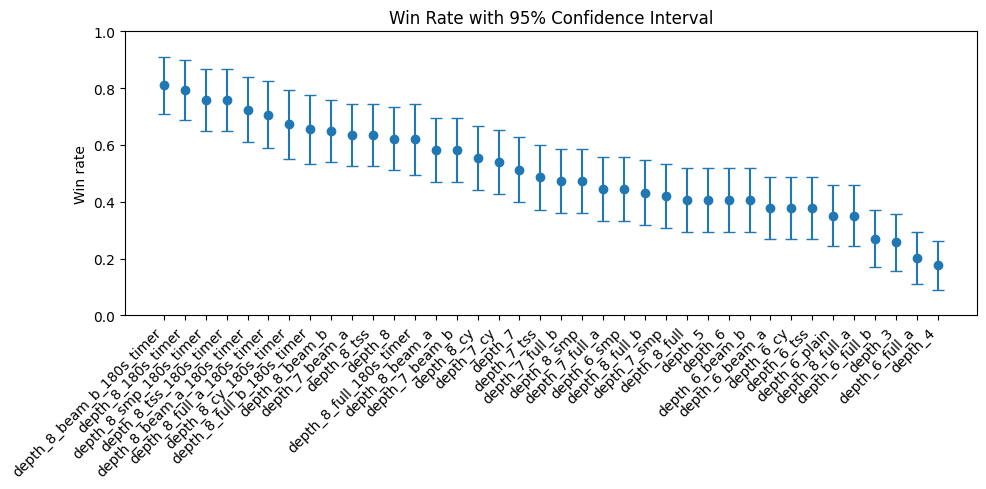

In [55]:
# Confidence interval (95%) cho win rate theo agent
if not df.empty:
    # Per-agent game outcomes
    rows = []
    for _, r in df.iterrows():
        rows.append({'agent': r['x_label'], 'win': 1 if r['winner'] == r['x_label'] else 0, 'game': 1})
        rows.append({'agent': r['o_label'], 'win': 1 if r['winner'] == r['o_label'] else 0, 'game': 1})
    wr = pd.DataFrame(rows).groupby('agent', as_index=False).agg(games=('game', 'sum'), wins=('win', 'sum'))
    wr['win_rate'] = wr['wins'] / wr['games']

    # Normal approximation CI
    z = 1.96
    wr['se'] = (wr['win_rate'] * (1 - wr['win_rate']) / wr['games']).pow(0.5)
    wr['ci_low'] = (wr['win_rate'] - z * wr['se']).clip(lower=0)
    wr['ci_high'] = (wr['win_rate'] + z * wr['se']).clip(upper=1)
    wr = wr.sort_values('win_rate', ascending=False).reset_index(drop=True)

    print('=== WIN RATE WITH 95% CI ===')
    display(wr[['agent', 'games', 'wins', 'win_rate', 'ci_low', 'ci_high']])

    plt.figure(figsize=(10, 5))
    plt.errorbar(
        x=wr['agent'],
        y=wr['win_rate'],
        yerr=[wr['win_rate'] - wr['ci_low'], wr['ci_high'] - wr['win_rate']],
        fmt='o', capsize=4
    )
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.title('Win Rate with 95% Confidence Interval')
    plt.ylabel('Win rate')
    plt.tight_layout()
    plt.show()


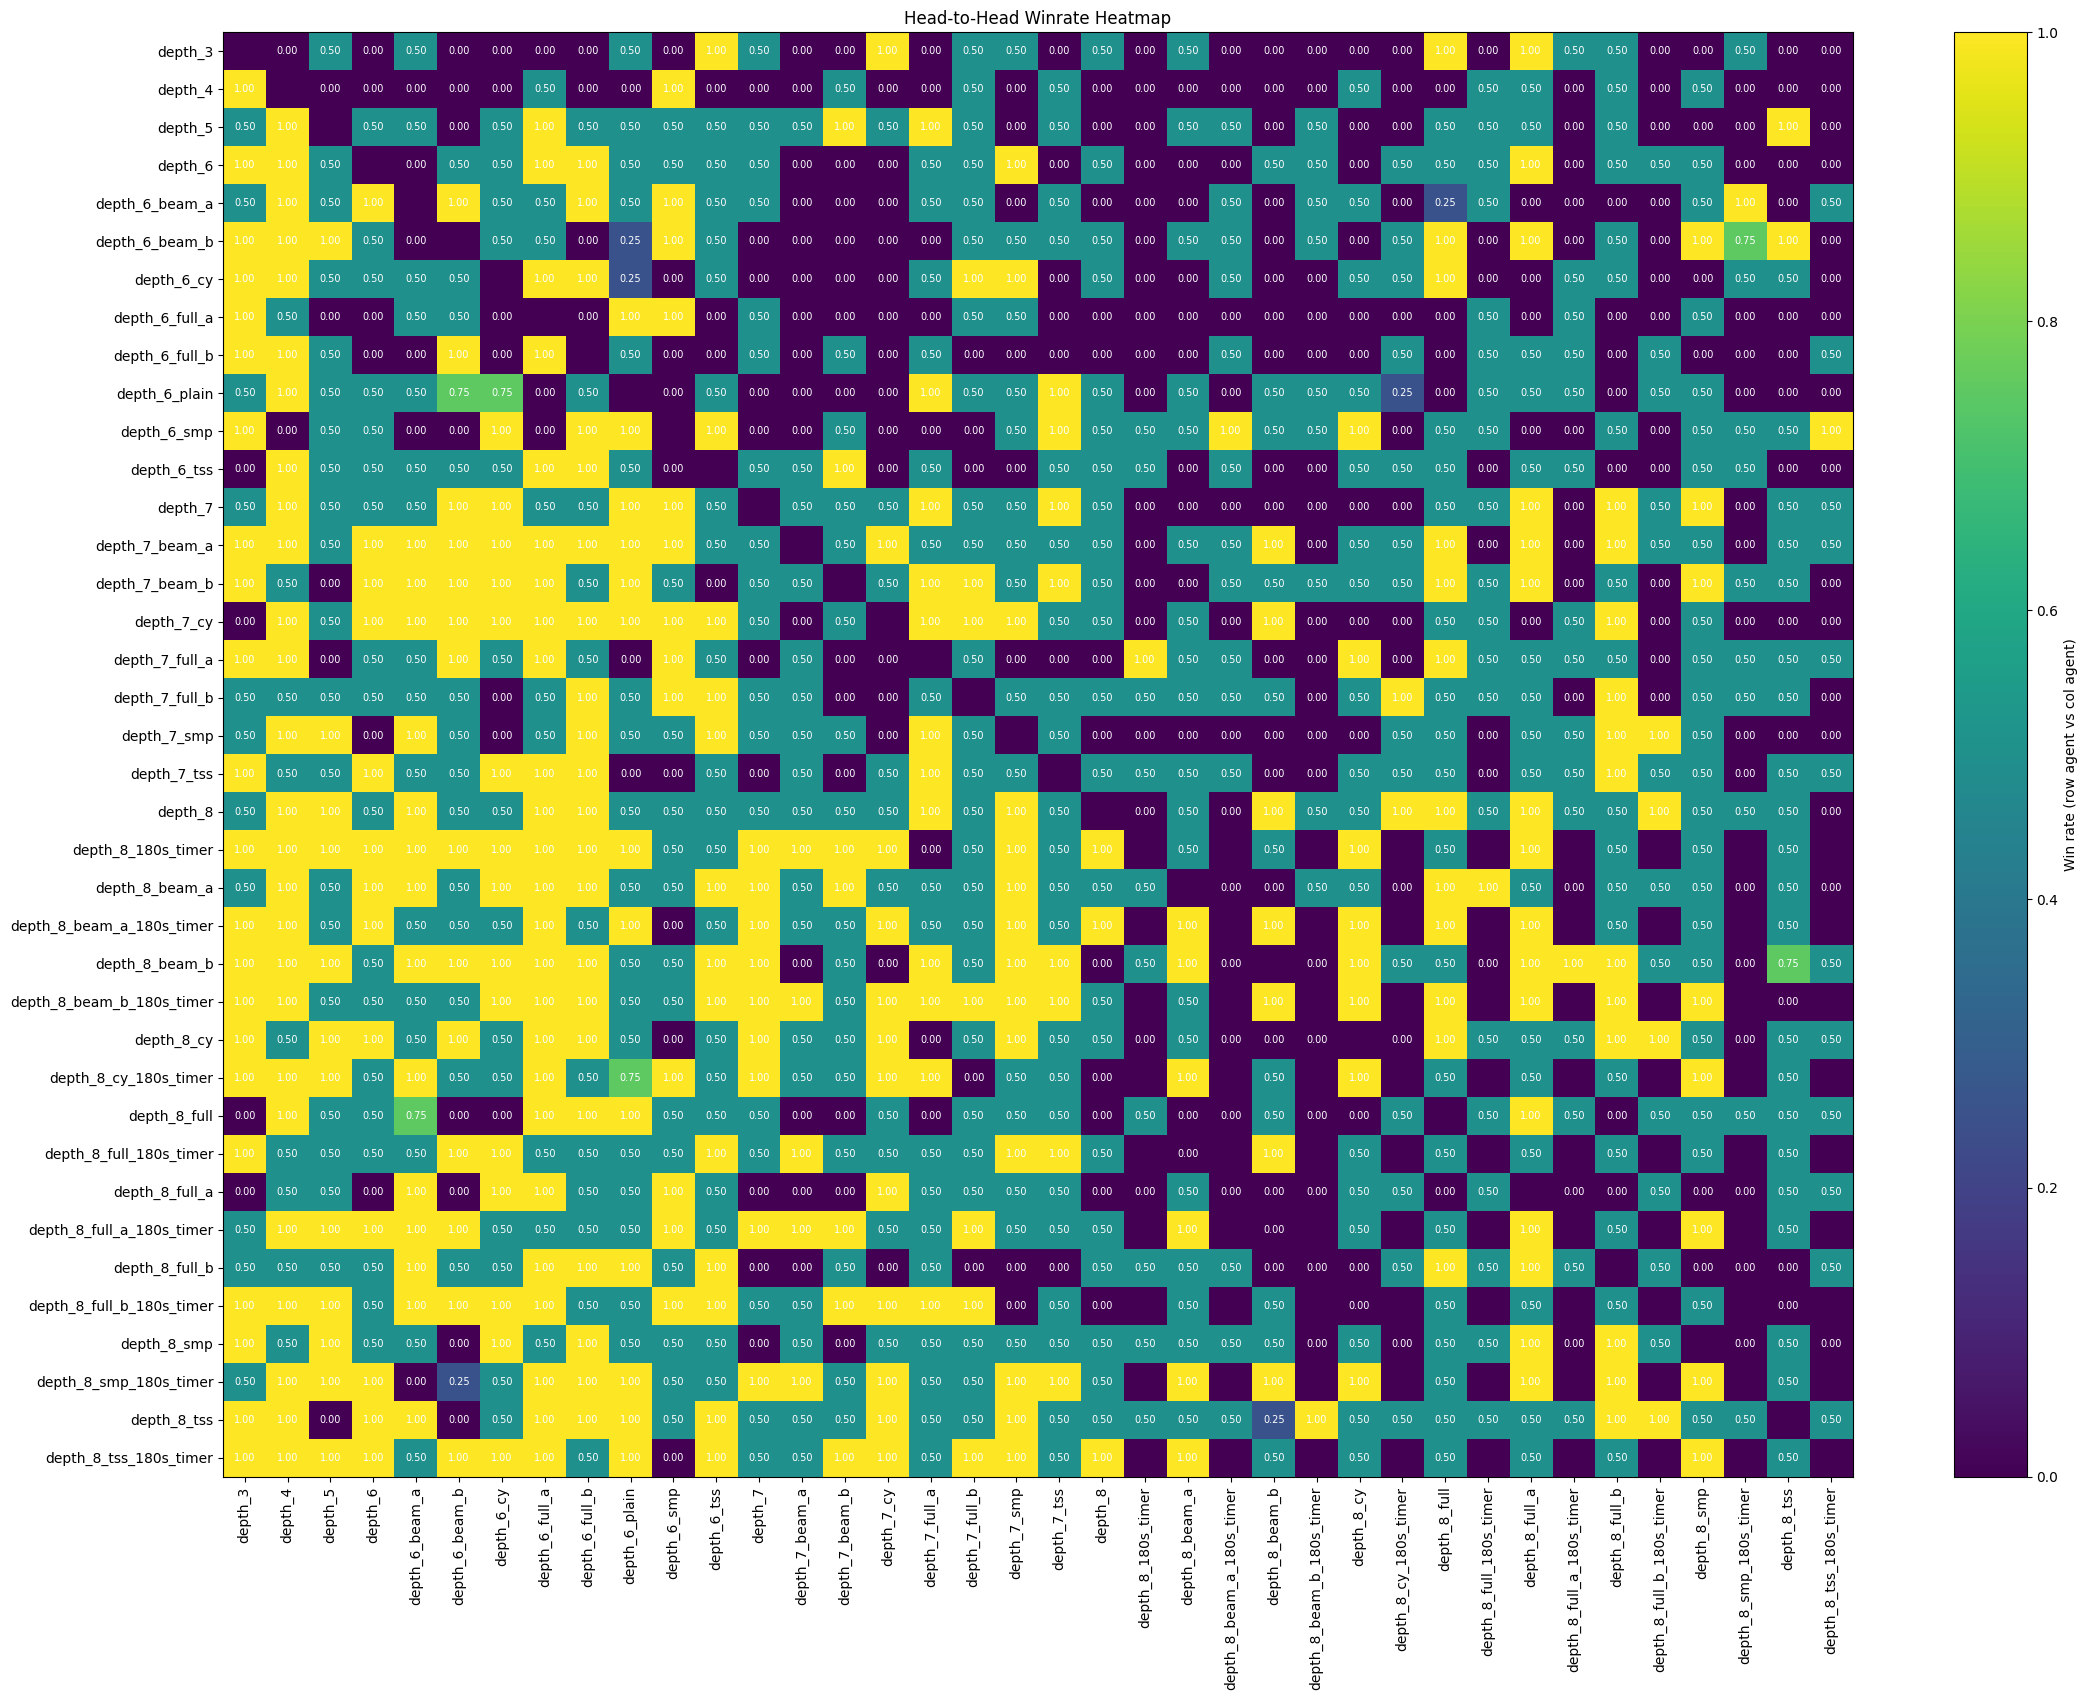

,depth_3,depth_4,depth_5,depth_6,depth_6_beam_a,depth_6_beam_b,depth_6_cy,depth_6_full_a,depth_6_full_b,depth_6_plain,...,depth_8_full,depth_8_full_180s_timer,depth_8_full_a,depth_8_full_a_180s_timer,depth_8_full_b,depth_8_full_b_180s_timer,depth_8_smp,depth_8_smp_180s_timer,depth_8_tss,depth_8_tss_180s_timer
depth_3,NaN,0.0,0.5,0.0,0.50,0.00,0.00,0.0,0.0,0.50,...,1.00,0.0,1.0,0.5,0.5,0.0,0.0,0.50,0.00,0.0
depth_4,1.0,NaN,0.0,0.0,0.00,0.00,0.00,0.5,0.0,0.00,...,0.00,0.5,0.5,0.0,0.5,0.0,0.5,0.00,0.00,0.0
depth_5,0.5,1.0,NaN,0.5,0.50,0.00,0.50,1.0,0.5,0.50,...,0.50,0.5,0.5,0.0,0.5,0.0,0.0,0.00,1.00,0.0
depth_6,1.0,1.0,0.5,NaN,0.00,0.50,0.50,1.0,1.0,0.50,...,0.50,0.5,1.0,0.0,0.5,0.5,0.5,0.00,0.00,0.0
depth_6_beam_a,0.5,1.0,0.5,1.0,NaN,1.00,0.50,0.5,1.0,0.50,...,0.25,0.5,0.0,0.0,0.0,0.0,0.5,1.00,0.00,0.5
depth_6_beam_b,1.0,1.0,1.0,0.5,0.00,NaN,0.50,0.5,0.0,0.25,...,1.00,0.0,1.0,0.0,0.5,0.0,1.0,0.75,1.00,0.0
depth_6_cy,1.0,1.0,0.5,0.5,0.50,0.50,NaN,1.0,1.0,0.25,...,1.00,0.0,0.0,0.5,0.5,0.0,0.0,0.50,0.50,0.0
depth_6_full_a,1.0,0.5,0.0,0.0,0.50,0.50,0.00,NaN,0.0,1.00,...,0.00,0.5,0.0,0.5,0.0,0.0,0.5,0.00,0.00,0.0
depth_6_full_b,1.0,1.0,0.5,0.0,0.00,1.00,0.00,1.0,NaN,0.50,...,0.00,0.5,0.5,0.5,0.0,0.5,0.0,0.00,0.00,0.5
depth_6_plain,0.5,1.0,0.5,0.5,0.50,0.75,0.75,0.0,0.5,NaN,...,0.00,0.5,0.5,0.5,0.0,0.5,0.5,0.00,0.00,0.0


In [56]:
# Heatmap winrate theo cap depth/profile (agent label)
if not df.empty:
    # Head-to-head matrix: row agent A vs col agent B => P(A wins)
    agents = sorted(set(df['x_label']).union(set(df['o_label'])))
    wins = pd.DataFrame(0.0, index=agents, columns=agents)
    games = pd.DataFrame(0.0, index=agents, columns=agents)

    for _, r in df.iterrows():
        a = r['x_label']
        b = r['o_label']
        games.loc[a, b] += 1
        games.loc[b, a] += 1
        if r['winner'] == 'draw' or r['winner_code'] == 2:
            wins.loc[a, b] += 0.5
            wins.loc[b, a] += 0.5
        elif r['winner'] == a:
            wins.loc[a, b] += 1.0
        else:
            wins.loc[b, a] += 1.0

    # pandas >= 2.x removed `mode.use_inf_as_na`; use explicit safe division.
    denom = games.where(games != 0, pd.NA)
    winrate_mat = wins.divide(denom)

    plt.figure(figsize=(max(8, len(agents)*0.6), max(6, len(agents)*0.45)))
    plt.imshow(winrate_mat.fillna(0.0).values, cmap='viridis', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(label='Win rate (row agent vs col agent)')
    plt.xticks(range(len(agents)), agents, rotation=90)
    plt.yticks(range(len(agents)), agents)
    plt.title('Head-to-Head Winrate Heatmap')

    # annotate values (optional but useful)
    for i in range(len(agents)):
        for j in range(len(agents)):
            val = winrate_mat.iloc[i, j]
            if pd.notna(val):
                plt.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=7, color='white')

    plt.tight_layout()
    plt.show()

    display(winrate_mat)


In [57]:
# Danh gia cap agent 'ngang tai ngang suc' theo head-to-head
if not df.empty:
    pair_rows = []
    for _, r in df.iterrows():
        a, b = sorted([r['x_label'], r['o_label']])
        key = f"{a}__vs__{b}"

        if r['winner'] == 'draw' or r['winner_code'] == 2:
            score_a = 0.5
            score_b = 0.5
        elif r['winner'] == a:
            score_a = 1.0
            score_b = 0.0
        else:
            score_a = 0.0
            score_b = 1.0

        pair_rows.append({
            'pair_key': key,
            'agent_a': a,
            'agent_b': b,
            'score_a': score_a,
            'score_b': score_b,
            'total_moves': r['total_moves'],
            'x_avg_move_sec': r['x_avg_move_sec'],
            'o_avg_move_sec': r['o_avg_move_sec'],
            'game_move_time_mean': (r['x_avg_move_sec'] + r['o_avg_move_sec']) / 2.0,
        })

    pair_df = pd.DataFrame(pair_rows)
    pair_summary = pair_df.groupby(['pair_key', 'agent_a', 'agent_b'], as_index=False).agg(
        games=('pair_key', 'count'),
        score_a_sum=('score_a', 'sum'),
        score_b_sum=('score_b', 'sum'),
        avg_total_moves=('total_moves', 'mean'),
        max_total_moves=('total_moves', 'max'),
        avg_game_move_time=('game_move_time_mean', 'mean'),
    )

    pair_summary['win_rate_a'] = pair_summary['score_a_sum'] / pair_summary['games']
    pair_summary['win_rate_b'] = pair_summary['score_b_sum'] / pair_summary['games']
    pair_summary['balance_gap'] = (pair_summary['win_rate_a'] - 0.5).abs()

    # Balance score: cang gan 50-50 va cang nhieu nuoc thi cang "ngang suc"
    eps = 1e-9
    norm_len = pair_summary['avg_total_moves'] / (pair_summary['avg_total_moves'].max() + eps)
    pair_summary['balance_score'] = 0.7 * (1 - 2 * pair_summary['balance_gap']) + 0.3 * norm_len

    pair_summary = pair_summary.sort_values('balance_score', ascending=False)

    print('=== CAP AGENT NGANG TAI (theo balance_score) ===')
    display(pair_summary[['pair_key', 'games', 'win_rate_a', 'win_rate_b', 'avg_total_moves', 'max_total_moves', 'avg_game_move_time', 'balance_score']])


=== CAP AGENT NGANG TAI (theo balance_score) ===


,pair_key,games,win_rate_a,win_rate_b,avg_total_moves,max_total_moves,avg_game_move_time,balance_score
235,depth_6_cy__vs__depth_8_smp_180s_timer,2,0.5,0.5,164.0,260,34.353650,0.896407
143,depth_6_beam_a__vs__depth_6_cy,2,0.5,0.5,152.0,154,3.930950,0.882036
175,depth_6_beam_b__vs__depth_6_cy,2,0.5,0.5,145.0,145,2.702250,0.873653
160,depth_6_beam_a__vs__depth_8_beam_a_180s_timer,2,0.5,0.5,138.0,148,12.623225,0.865269
129,depth_6__vs__depth_8_beam_b_180s_timer,2,0.5,0.5,132.0,159,13.350575,0.858084
...,...,...,...,...,...,...,...,...
429,depth_7_beam_b__vs__depth_7_full_b,2,1.0,0.0,20.5,21,9.538075,0.024551
466,depth_7_cy__vs__depth_8_full_b,2,1.0,0.0,20.5,21,9.540275,0.024551
28,depth_3__vs__depth_8_full_180s_timer,2,0.0,1.0,20.5,24,32.369775,0.024551
32,depth_3__vs__depth_8_full_b_180s_timer,2,0.0,1.0,20.5,24,38.855125,0.024551


=== TOP 10 TRAN CO SO NUOC DI NHIEU NHAT ===


,match_id,x_label,o_label,winner,x_depth,o_depth,total_moves,x_avg_move_sec,o_avg_move_sec
671,depth_6_plain_vs_depth_6_cy_auto__game_2,depth_6_cy,depth_6_plain,draw,6,6,360,5.3985,5.0981
695,depth_8_full_vs_depth_6_beam_a_auto__game_2,depth_6_beam_a,depth_8_full,draw,6,8,360,5.6141,16.1176
1004,depth_8_cy_180s_timer_vs_depth_6_plain_auto__g...,depth_8_cy_180s_timer,depth_6_plain,draw,8,6,360,50.7185,6.2142
938,depth_8_smp_180s_timer_vs_depth_6_beam_b_auto_...,depth_8_smp_180s_timer,depth_6_beam_b,draw,8,6,360,96.5583,4.9639
675,depth_6_plain_vs_depth_6_beam_b_auto__game_2,depth_6_beam_b,depth_6_plain,draw,6,6,360,6.1945,6.9402
383,depth_8_tss_vs_depth_8_beam_b_auto__game_2,depth_8_beam_b,depth_8_tss,draw,8,8,360,14.1859,14.8016
941,depth_8_smp_180s_timer_vs_depth_6_cy_auto__game_2,depth_6_cy,depth_8_smp_180s_timer,depth_8_smp_180s_timer,6,8,260,3.7255,77.8058
732,depth_6_smp_vs_depth_6_beam_a_auto__game_1,depth_6_smp,depth_6_beam_a,depth_6_beam_a,6,6,242,10.5971,3.6427
1121,depth_8_beam_b_180s_timer_vs_depth_6_plain_aut...,depth_6_plain,depth_8_beam_b_180s_timer,depth_6_plain,6,8,217,3.7376,26.4736
252,depth_7_vs_depth_8_beam_a_auto__game_1,depth_7,depth_8_beam_a,depth_8_beam_a,7,8,214,6.5546,10.5976


/tmp/ipykernel_2427000/1017262048.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


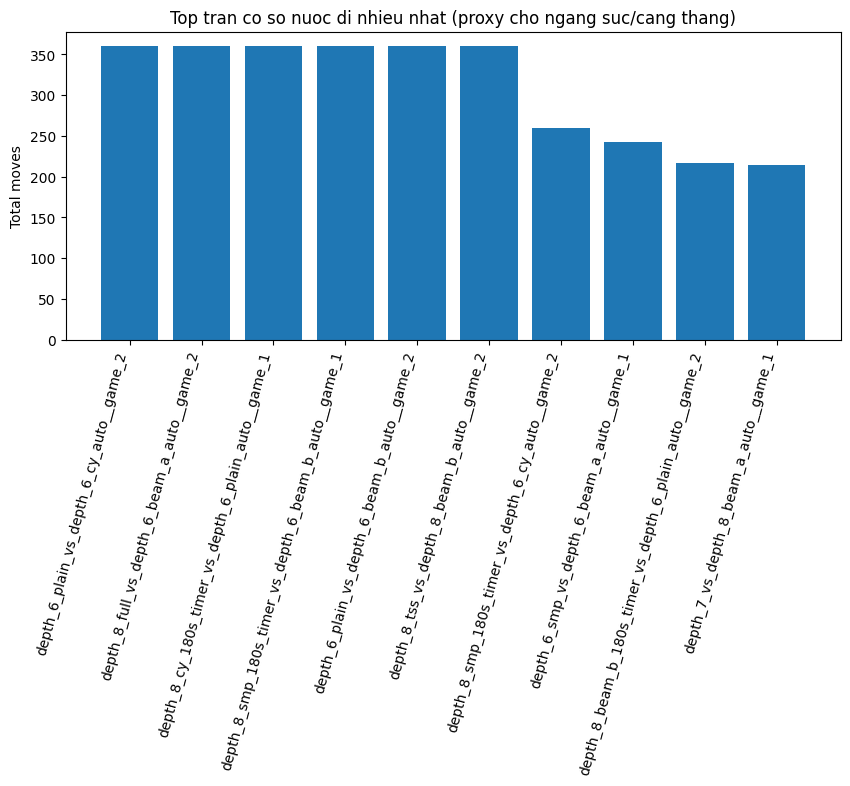

=== TOP 10 TRAN CO SO NUOC DI IT NHAT ===


,match_id,x_label,o_label,winner,x_depth,o_depth,total_moves,x_avg_move_sec,o_avg_move_sec
1191,depth_8_full_180s_timer_vs_depth_7_cy_auto__ga...,depth_7_cy,depth_8_full_180s_timer,depth_7_cy,7,8,15,3.7941,72.8786
1216,depth_8_full_180s_timer_vs_depth_8_tss_auto__g...,depth_8_full_180s_timer,depth_8_tss,depth_8_full_180s_timer,8,8,15,51.9486,10.9696
1233,depth_8_full_a_180s_timer_vs_depth_6_full_a_au...,depth_6_full_a,depth_8_full_a_180s_timer,depth_6_full_a,6,8,15,7.9704,69.0693
1235,depth_8_full_a_180s_timer_vs_depth_6_full_b_au...,depth_6_full_b,depth_8_full_a_180s_timer,depth_6_full_b,6,8,15,8.6664,71.4210
887,depth_8_tss_180s_timer_vs_depth_6_full_b_auto_...,depth_6_full_b,depth_8_tss_180s_timer,depth_6_full_b,6,8,15,8.8344,13.8177
1189,depth_8_full_180s_timer_vs_depth_7_beam_b_auto...,depth_7_beam_b,depth_8_full_180s_timer,depth_7_beam_b,7,8,15,3.8260,72.7821
1177,depth_8_full_180s_timer_vs_depth_6_full_b_auto...,depth_6_full_b,depth_8_full_180s_timer,depth_6_full_b,6,8,15,8.5752,71.5190
897,depth_8_tss_180s_timer_vs_depth_7_beam_a_auto_...,depth_7_beam_a,depth_8_tss_180s_timer,depth_7_beam_a,7,8,15,3.7197,14.1611
403,depth_8_tss_vs_depth_7_beam_a_auto__game_2,depth_7_beam_a,depth_8_tss,depth_7_beam_a,7,8,15,4.8540,10.7530
1175,depth_8_full_180s_timer_vs_depth_6_full_a_auto...,depth_6_full_a,depth_8_full_180s_timer,depth_6_full_a,6,8,15,8.1655,72.9721


/tmp/ipykernel_2427000/1017262048.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


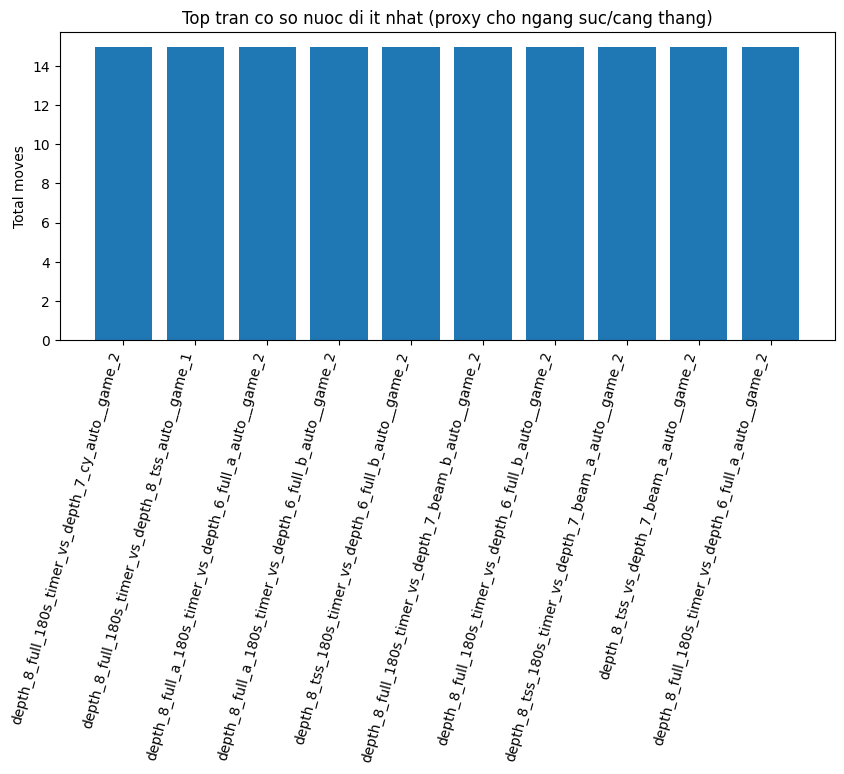

=== CAP CAN BANG (40%-60%) VA CO TRAN DAI ===


,pair_key,games,win_rate_a,win_rate_b,avg_total_moves,max_total_moves,balance_score
235,depth_6_cy__vs__depth_8_smp_180s_timer,2,0.5,0.5,164.0,260,0.896407
143,depth_6_beam_a__vs__depth_6_cy,2,0.5,0.5,152.0,154,0.882036
175,depth_6_beam_b__vs__depth_6_cy,2,0.5,0.5,145.0,145,0.873653
160,depth_6_beam_a__vs__depth_8_beam_a_180s_timer,2,0.5,0.5,138.0,148,0.865269
129,depth_6__vs__depth_8_beam_b_180s_timer,2,0.5,0.5,132.0,159,0.858084
...,...,...,...,...,...,...,...
408,depth_7_beam_a__vs__depth_7_tss,2,0.5,0.5,19.0,21,0.722754
635,depth_8_full_180s_timer__vs__depth_8_tss,2,0.5,0.5,19.0,23,0.722754
666,depth_8_tss__vs__depth_8_tss_180s_timer,2,0.5,0.5,19.0,23,0.722754
426,depth_7_beam_a__vs__depth_8_tss_180s_timer,2,0.5,0.5,17.0,19,0.720359


In [58]:
# Top tran 'can nao' theo so nuoc di nhieu nhat
if not df.empty:
    top_long_games = df.sort_values('total_moves', ascending=False).head(10).copy()
    top_long_games = top_long_games[['match_id', 'x_label', 'o_label', 'winner', 'x_depth', 'o_depth', 'total_moves', 'x_avg_move_sec', 'o_avg_move_sec']]

    print('=== TOP 10 TRAN CO SO NUOC DI NHIEU NHAT ===')
    display(top_long_games)

    plt.figure(figsize=(10, 4))
    plt.bar(top_long_games['match_id'], top_long_games['total_moves'])
    plt.xticks(rotation=75, ha='right')
    plt.title('Top tran co so nuoc di nhieu nhat (proxy cho ngang suc/cang thang)')
    plt.ylabel('Total moves')
    plt.tight_layout()
    plt.show()
    
    
    top_sort_games = df.sort_values('total_moves').head(10).copy()
    top_sort_games = top_sort_games[['match_id', 'x_label', 'o_label', 'winner', 'x_depth', 'o_depth', 'total_moves', 'x_avg_move_sec', 'o_avg_move_sec']]

    print('=== TOP 10 TRAN CO SO NUOC DI IT NHAT ===')
    display(top_sort_games)

    plt.figure(figsize=(10, 4))
    plt.bar(top_sort_games['match_id'], top_sort_games['total_moves'])
    plt.xticks(rotation=75, ha='right')
    plt.title('Top tran co so nuoc di it nhat (proxy cho ngang suc/cang thang)')
    plt.ylabel('Total moves')
    plt.tight_layout()
    plt.show()

    # Cac cap vua can bang vua dai tran (thuc dung)
    if 'pair_summary' in globals():
        close_pairs = pair_summary[(pair_summary['win_rate_a'].between(0.4, 0.6)) & (pair_summary['games'] >= 2)]
        close_pairs = close_pairs.sort_values(['avg_total_moves', 'balance_score'], ascending=False)
        print('=== CAP CAN BANG (40%-60%) VA CO TRAN DAI ===')
        display(close_pairs[['pair_key', 'games', 'win_rate_a', 'win_rate_b', 'avg_total_moves', 'max_total_moves', 'balance_score']])


=== Tong Thoi Gian Moi Tran Trung Binh Theo Agent ===


,agent,depth,games,wins,win_rate,avg_game_total_time_sec,median_game_total_time_sec,avg_moves,finishing_score
37,depth_8_tss_180s_timer,8,58,44,0.758621,301.681066,225.17675,17.068966,0.816997
13,depth_7_beam_a,7,74,47,0.635135,77.146992,66.69390,16.662162,0.737539
25,depth_8_beam_b_180s_timer,8,58,47,0.810345,546.185479,250.71340,30.793103,0.725754
31,depth_8_full_a_180s_timer,8,58,41,0.706897,1932.794133,1277.23015,21.465517,0.722219
29,depth_8_full_180s_timer,8,58,36,0.620690,1488.961559,1102.48700,17.586207,0.712034
21,depth_8_180s_timer,8,58,46,0.793103,520.799136,413.58655,31.948276,0.707953
33,depth_8_full_b_180s_timer,8,58,38,0.655172,2029.453188,1317.30280,21.379310,0.686929
15,depth_7_cy,7,74,40,0.540541,66.991334,54.76325,16.270270,0.678378
35,depth_8_smp_180s_timer,8,58,44,0.758621,2330.617086,1505.41920,35.258621,0.669471
23,depth_8_beam_a_180s_timer,8,58,42,0.724138,556.596814,317.47300,32.051724,0.659184


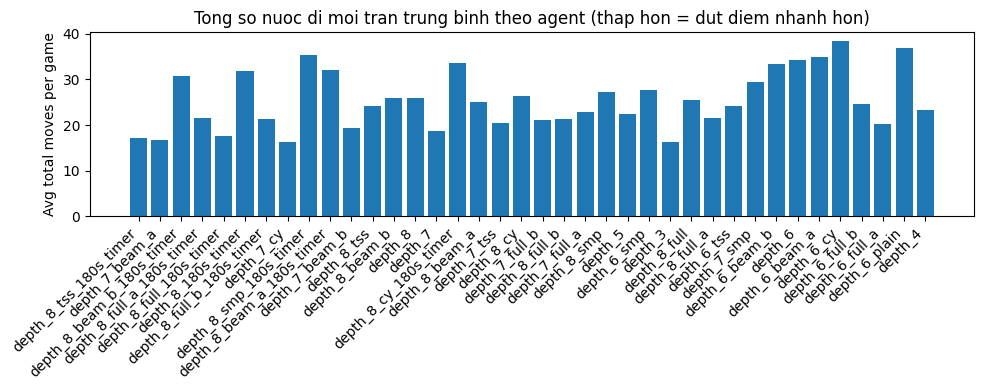

In [59]:
# Tong thoi gian moi tran trung binh theo agent (proxy kha nang dut diem)
# Dinh nghia: game_total_time_agent ~= avg_move_sec * moves cua agent trong tran
if not df.empty:
    finish_rows = []
    for _, r in df.iterrows():
        finish_rows.append({
            'agent': r['x_label'],
            'depth': r['x_depth'],
            'game_total_time_sec': float(r['x_avg_move_sec']) * float(r['x_moves']),
            'moves': r['x_moves'],
            'won': 1 if r['winner'] == r['x_label'] else 0,
        })
        finish_rows.append({
            'agent': r['o_label'],
            'depth': r['o_depth'],
            'game_total_time_sec': float(r['o_avg_move_sec']) * float(r['o_moves']),
            'moves': r['o_moves'],
            'won': 1 if r['winner'] == r['o_label'] else 0,
        })

    finish_df = pd.DataFrame(finish_rows)
    finish_summary = finish_df.groupby(['agent', 'depth'], as_index=False).agg(
        games=('agent', 'count'),
        wins=('won', 'sum'),
        avg_game_total_time_sec=('game_total_time_sec', 'mean'),
        median_game_total_time_sec=('game_total_time_sec', 'median'),
        avg_moves=('moves', 'mean'),
    )
    finish_summary['win_rate'] = finish_summary['wins'] / finish_summary['games']

    # Chi so dut diem: thang cao, tong thoi gian/van thap
    eps = 1e-9
    speed_finish = 1.0 / (finish_summary['avg_moves'] + eps)
    speed_finish_norm = speed_finish / speed_finish.max()
    finish_summary['finishing_score'] = 0.7 * finish_summary['win_rate'] + 0.3 * speed_finish_norm
    finish_summary = finish_summary.sort_values('finishing_score', ascending=False)

    print('=== Tong Thoi Gian Moi Tran Trung Binh Theo Agent ===')
    display(finish_summary[['agent', 'depth', 'games', 'wins', 'win_rate', 'avg_game_total_time_sec', 'median_game_total_time_sec', 'avg_moves', 'finishing_score']])

    plt.figure(figsize=(10, 4))
    plt.bar(finish_summary['agent'], finish_summary['avg_moves'])
    plt.xticks(rotation=45, ha='right')
    plt.title('Tong so nuoc di moi tran trung binh theo agent (thap hon = dut diem nhanh hon)')
    plt.ylabel('Avg total moves per game')
    plt.tight_layout()
    plt.show()
